# M6 – Autoencoder đa nhiệm cho tái tạo tín hiệu PPG và nhận dạng hoạt động

**Học phần:** Trí tuệ nhân tạo cho IoT – AIOT331185  
**Đề tài:** M6 – Dual-Task Autoencoder  
**Dataset:** PPG-DaLiA bản đồng bộ theo subject (`PPG_FieldStudy`)  
**Đầu vào chính:** Wrist BVP/PPG, 1 kênh, 64 Hz

## Mục tiêu thực nghiệm

Notebook này bám theo đề cương M6 đã chỉnh sửa và kiểm tra đồng thời:

1. chất lượng phân loại hoạt động bằng Accuracy, Macro-F1 và F1 từng lớp;
2. chất lượng tái tạo bằng MSE và PRD_c trên miền tín hiệu chuẩn hóa;
3. khác biệt GAP và Flatten ở nhánh phân loại;
4. vai trò của học đa nhiệm bằng đối chứng MTL-GAP ↔ CNN-GAP và MTL-Flat ↔ CNN-Flat;
5. số tham số, dung lượng trọng số và độ trễ suy luận CPU;
6. độ ổn định qua các seed 42, 43, 44.

## Năm cấu hình chính

- MTL-GAP
- MTL-Flat
- CNN-GAP
- CNN-Flat
- AE

Thí nghiệm chính gồm **5 cấu hình × 3 seed = 15 lượt**. Ngoài ra có khảo sát độ nhạy `γ` trên Validation theo đúng ma trận bổ sung của đề cương.


# Phase 0 – Project Setup

Thiết lập môi trường, đường dẫn, seed và cấu hình cố định trước khi xử lý dữ liệu.

Các nguyên tắc khóa từ đầu:

- Train: S1–S9;
- Validation: S10–S12;
- Test: S13–S15;
- BVP 64 Hz;
- cửa sổ 8 giây = 512 mẫu;
- stride 4 giây = 256 mẫu;
- không thêm band-pass filter trong thí nghiệm chính;
- normalization dùng một cặp `μ_train`, `σ_train` chung học từ Train;
- không dùng class weighting, augmentation hoặc resampling trong thí nghiệm chính.


In [24]:
# PHASE 0 - PROJECT SETUP

import os
import sys
import json
import time
import math
import copy
import random
import pickle
import platform
import zipfile
import gc
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

import sklearn
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    confusion_matrix
)

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader


PROJECT_ROOT = Path.cwd()
DATA_ROOT = PROJECT_ROOT / "data" / "PPG_FieldStudy"

FIGURE_DIR = PROJECT_ROOT / "figures"
PROCESSED_DIR = PROJECT_ROOT / "processed"
CHECKPOINT_DIR = PROJECT_ROOT / "checkpoints"
RESULTS_DIR = PROJECT_ROOT / "results"
CONFIG_DIR = PROJECT_ROOT / "configs"

for directory in [
    FIGURE_DIR,
    PROCESSED_DIR,
    CHECKPOINT_DIR,
    RESULTS_DIR,
    CONFIG_DIR
]:
    directory.mkdir(exist_ok=True)


device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)


def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


CONFIG = {
    "dataset_name": "PPG-DaLiA / PPG_FieldStudy",
    "subjects": [f"S{i}" for i in range(1, 16)],
    "train_subjects": [f"S{i}" for i in range(1, 10)],
    "val_subjects": [f"S{i}" for i in range(10, 13)],
    "test_subjects": [f"S{i}" for i in range(13, 16)],

    "fs": 64,
    "window_size": 512,
    "stride": 256,
    "num_classes": 8,

    "batch_size": 64,
    "learning_rate": 1e-3,
    "weight_decay": 0.0,
    "max_epochs": 100,
    "patience": 10,

    "gamma_main": 1.0,
    "gamma_sensitivity": [0.0, 0.1, 0.5, 1.0, 2.0],

    "seeds": [42, 43, 44],

    "input_channels": 1,
    "bottleneck_channels": 128,
    "bottleneck_length": 64,
    "gap_feature_dim": 128,
    "flatten_feature_dim": 128 * 64,
    "hidden_dim": 128,
    "dropout": 0.2,

    "main_filter": None,
    "normalization": "train_global_zscore",

    "latency_cpu_threads": 1,
    "latency_warmup": 100,
    "latency_iterations": 1000,
    "latency_sessions": 3
}


set_seed(CONFIG["seeds"][0])


print("Python       :", sys.version.split()[0])
print("NumPy        :", np.__version__)
print("Pandas       :", pd.__version__)
print("Scikit-learn :", sklearn.__version__)
print("Matplotlib   :", matplotlib.__version__)
print("PyTorch      :", torch.__version__)

print("\nDevice       :", device)
print("CUDA         :", torch.cuda.is_available())

if torch.cuda.is_available():
    print(
        "GPU          :",
        torch.cuda.get_device_name(0)
    )

print("\nProject root :", PROJECT_ROOT)
print("Dataset path :", DATA_ROOT)
print("Dataset found:", DATA_ROOT.exists())

print("\nTrain:", CONFIG["train_subjects"])
print("Val  :", CONFIG["val_subjects"])
print("Test :", CONFIG["test_subjects"])

print("\nMain filter  :", CONFIG["main_filter"])
print("Normalization:", CONFIG["normalization"])
print("Window       :", CONFIG["window_size"])
print("Stride       :", CONFIG["stride"])
print("Seeds        :", CONFIG["seeds"])

assert DATA_ROOT.exists(), (
    "Không tìm thấy data/PPG_FieldStudy. "
    "Hãy đặt dataset đúng cấu trúc project trước khi Run All."
)


Python       : 3.10.20
NumPy        : 2.2.6
Pandas       : 2.3.3
Scikit-learn : 1.7.2
Matplotlib   : 3.10.9
PyTorch      : 2.14.0+cu126

Device       : cuda
CUDA         : True
GPU          : NVIDIA GeForce RTX 4060 Laptop GPU

Project root : d:\IOT_AI\Dual_Task_Autoencoder
Dataset path : d:\IOT_AI\Dual_Task_Autoencoder\data\PPG_FieldStudy
Dataset found: True

Train: ['S1', 'S2', 'S3', 'S4', 'S5', 'S6', 'S7', 'S8', 'S9']
Val  : ['S10', 'S11', 'S12']
Test : ['S13', 'S14', 'S15']

Main filter  : None
Normalization: train_global_zscore
Window       : 512
Stride       : 256
Seeds        : [42, 43, 44]


# Phase 0 – Kết luận

Môi trường thực nghiệm đã được thiết lập và chạy thành công trên:

- Python **3.10.20**;
- PyTorch **2.14.0+cu126**;
- GPU **NVIDIA GeForce RTX 4060 Laptop GPU**;
- CUDA khả dụng.

Cấu hình chính được khóa đúng theo đề cương:

- Train: **S1–S9**;
- Validation: **S10–S12**;
- Test: **S13–S15**;
- BVP: **64 Hz**;
- window: **512 mẫu = 8 giây**;
- stride: **256 mẫu = 4 giây**, overlap 50%;
- seed: **42, 43, 44**;
- **không dùng band-pass filter** trong thí nghiệm chính;
- normalization: **global z-score chỉ học từ Train**.

Các cấu hình này được giữ cố định cho toàn bộ thí nghiệm chính.

# Phase 1 – Data Understanding

Mục tiêu:

- xác nhận cấu trúc S1–S15;
- xác định đúng trường `signal.wrist.BVP`;
- xác định đúng trường `activity`;
- không dùng trường `label` chứa thông tin HR làm nhãn hoạt động;
- kiểm tra sampling rate và độ dài BVP/activity;
- xác định 8 activity chính và đặc điểm thiếu lớp theo từng subject nếu có.


In [25]:
# PHASE 1.1 - DATASET STRUCTURE

structure_rows = []

for subject_id in CONFIG["subjects"]:
    subject_dir = DATA_ROOT / subject_id

    structure_rows.append({
        "subject": subject_id,
        "folder": subject_dir.exists(),
        "pkl": (
            subject_dir / f"{subject_id}.pkl"
        ).exists(),
        "activity_csv": (
            subject_dir / f"{subject_id}_activity.csv"
        ).exists(),
        "e4_source": (
            (subject_dir / f"{subject_id}_E4").exists()
            or
            (subject_dir / f"{subject_id}_E4.zip").exists()
        )
    })

dataset_structure = pd.DataFrame(
    structure_rows
)

display(dataset_structure)

print(
    "Subjects :",
    dataset_structure["folder"].sum(),
    "/ 15"
)

print(
    "PKL      :",
    dataset_structure["pkl"].sum(),
    "/ 15"
)

print(
    "Activity :",
    dataset_structure["activity_csv"].sum(),
    "/ 15"
)

print(
    "E4 source:",
    dataset_structure["e4_source"].sum(),
    "/ 15"
)


,subject,folder,pkl,activity_csv,e4_source
0,S1,True,True,True,True
1,S2,True,True,True,True
2,S3,True,True,True,True
3,S4,True,True,True,True
4,S5,True,True,True,True
5,S6,True,True,True,True
6,S7,True,True,True,True
7,S8,True,True,True,True
8,S9,True,True,True,True
9,S10,True,True,True,True


Subjects : 15 / 15
PKL      : 15 / 15
Activity : 15 / 15
E4 source: 15 / 15


In [26]:
# PHASE 1.2 - INSPECT S1 PKL

import pickle
import numpy as np

s1_pkl_path = DATA_ROOT / "S1" / "S1.pkl"

with open(s1_pkl_path, "rb") as f:
    try:
        s1_data = pickle.load(f)
    except UnicodeDecodeError:
        f.seek(0)
        s1_data = pickle.load(
            f,
            encoding="latin1"
        )

print("Object type   :", type(s1_data).__name__)
print("Top-level keys:", list(s1_data.keys()))

print("\nSignal groups:")
print(list(s1_data["signal"].keys()))

print("\nWrist signals:")
print(list(s1_data["signal"]["wrist"].keys()))

bvp_signal = np.asarray(
    s1_data["signal"]["wrist"]["BVP"]
)

activity_array = np.asarray(
    s1_data["activity"]
)

print("\nBVP path      : root.signal.wrist.BVP")
print("BVP shape     :", bvp_signal.shape)
print("BVP dtype     :", bvp_signal.dtype)

print("\nActivity shape:", activity_array.shape)
print("Activity dtype:", activity_array.dtype)

print("\nSubject       :", s1_data.get("subject"))


Object type   : dict
Top-level keys: ['rpeaks', 'signal', 'label', 'activity', 'questionnaire', 'subject']

Signal groups:
['chest', 'wrist']

Wrist signals:
['ACC', 'BVP', 'EDA', 'TEMP']

BVP path      : root.signal.wrist.BVP
BVP shape     : (589568, 1)
BVP dtype     : float64

Activity shape: (36848, 1)
Activity dtype: float64

Subject       : S1


In [27]:
# PHASE 1.3 - ACTIVITY, METADATA AND CONSISTENCY

import gc
import zipfile


def locate_bvp_source(subject_id):
    subject_dir = DATA_ROOT / subject_id

    e4_dir = subject_dir / f"{subject_id}_E4"

    if e4_dir.exists():
        candidates = [
            p for p in e4_dir.rglob("*.csv")
            if "bvp" in p.name.lower()
        ]

        if len(candidates) == 1:
            return {
                "type": "file",
                "path": candidates[0],
                "member": None
            }

    e4_zip = subject_dir / f"{subject_id}_E4.zip"

    if e4_zip.exists():
        with zipfile.ZipFile(e4_zip, "r") as zf:
            members = [
                name
                for name in zf.namelist()
                if name.lower().endswith(".csv")
                and "bvp" in Path(name).name.lower()
            ]

        if len(members) == 1:
            return {
                "type": "zip",
                "path": e4_zip,
                "member": members[0]
            }

    return {
        "type": "not_found",
        "path": None,
        "member": None
    }


def read_bvp_header(source_info):
    if source_info["type"] == "file":
        df = pd.read_csv(
            source_info["path"],
            header=None,
            nrows=2
        )

    elif source_info["type"] == "zip":
        with zipfile.ZipFile(
            source_info["path"],
            "r"
        ) as zf:
            with zf.open(
                source_info["member"]
            ) as f:
                df = pd.read_csv(
                    f,
                    header=None,
                    nrows=2
                )

    else:
        return np.nan, np.nan

    start_unix = pd.to_numeric(
        df.iloc[0, 0],
        errors="coerce"
    )

    fs = pd.to_numeric(
        df.iloc[1, 0],
        errors="coerce"
    )

    return start_unix, fs


# Inspect S1 activity CSV
s1_activity_path = (
    DATA_ROOT / "S1" / "S1_activity.csv"
)

s1_activity_df = pd.read_csv(
    s1_activity_path
)

annotation_col = s1_activity_df.columns[0]
marker_col = s1_activity_df.columns[1]

annotations = (
    s1_activity_df[annotation_col]
    .astype(str)
    .str.replace("#", "", regex=False)
    .str.strip()
)

markers = pd.to_numeric(
    s1_activity_df[marker_col],
    errors="coerce"
)

excluded_annotations = {
    "NO_ACTIVITY",
    "CLEAN_BASELINE"
}

task_activities = list(dict.fromkeys(
    name
    for name in annotations
    if name not in excluded_annotations
))

print("S1 activity CSV shape:", s1_activity_df.shape)
print("Task activities       :", task_activities)
print("Number of activities  :", len(task_activities))

print(
    "Markers increasing    :",
    bool(
        markers.notna().all()
        and (markers.diff().dropna() > 0).all()
    )
)


# S1 metadata from E4
s1_source = locate_bvp_source("S1")

s1_start_unix, s1_fs = read_bvp_header(
    s1_source
)

print("\nS1 BVP source type :", s1_source["type"])
print("S1 BVP fs          :", s1_fs, "Hz")

print(
    "S1 start timestamp :",
    pd.to_datetime(
        s1_start_unix,
        unit="s",
        utc=True
    )
    if pd.notna(s1_start_unix)
    else "Not found"
)

print(
    "BVP fs matches CONFIG:",
    bool(
        pd.notna(s1_fs)
        and np.isclose(
            float(s1_fs),
            CONFIG["fs"]
        )
    )
)


# Quick consistency check S1-S15
inventory_rows = []

for subject_id in CONFIG["subjects"]:
    subject_dir = DATA_ROOT / subject_id

    pkl_path = (
        subject_dir
        / f"{subject_id}.pkl"
    )

    activity_path = (
        subject_dir
        / f"{subject_id}_activity.csv"
    )

    with open(pkl_path, "rb") as f:
        try:
            data = pickle.load(f)
        except UnicodeDecodeError:
            f.seek(0)
            data = pickle.load(
                f,
                encoding="latin1"
            )

    bvp = np.asarray(
        data["signal"]["wrist"]["BVP"]
    )

    activity = np.asarray(
        data["activity"]
    ).reshape(-1)

    source_info = locate_bvp_source(
        subject_id
    )

    start_unix, fs_direct = read_bvp_header(
        source_info
    )

    duration_s = (
        len(bvp) / float(fs_direct)
        if pd.notna(fs_direct)
        else np.nan
    )

    activity_df = pd.read_csv(
        activity_path
    )

    labels = np.unique(
        activity
    )

    task_labels = [
        int(x)
        for x in labels
        if np.isfinite(x)
        and float(x).is_integer()
        and 1 <= int(x) <= CONFIG["num_classes"]
    ]

    schema_ok = bool(
        data.get("subject") == subject_id
        and "signal" in data
        and "wrist" in data["signal"]
        and "BVP" in data["signal"]["wrist"]
        and "activity" in data
    )

    label_format_ok = bool(
        activity_df.shape[1] == 2
        and len(task_labels) > 0
        and all(
            1 <= label <= CONFIG["num_classes"]
            for label in task_labels
        )
    )

    inventory_rows.append({
        "subject": subject_id,
        "schema_ok": schema_ok,
        "bvp_dtype": str(bvp.dtype),
        "activity_dtype": str(activity.dtype),
        "bvp_fs_hz": fs_direct,
        "label_format_ok": label_format_ok,
        "bvp_samples": len(bvp),
        "duration_s": duration_s,
        "n_task_activities": len(task_labels),
        "task_labels": task_labels,
        "nan_count": int(
            np.isnan(bvp).sum()
        ),
        "inf_count": int(
            np.isinf(bvp).sum()
        )
    })

    del data, bvp, activity
    gc.collect()


subject_inventory = pd.DataFrame(
    inventory_rows
)

display(subject_inventory)


# Consistency conditions
fs_complete = (
    subject_inventory["bvp_fs_hz"]
    .notna()
    .all()
)

fs_consistent = (
    subject_inventory["bvp_fs_hz"]
    .dropna()
    .apply(
        lambda x: np.isclose(
            float(x),
            CONFIG["fs"]
        )
    )
    .all()
)

consistency_passed = bool(
    subject_inventory["schema_ok"].all()
    and subject_inventory["label_format_ok"].all()
    and subject_inventory["bvp_dtype"].nunique() == 1
    and subject_inventory["activity_dtype"].nunique() == 1
    and fs_complete
    and fs_consistent
)

print(
    "\nConsistency S1-S15:",
    "PASSED"
    if consistency_passed
    else "NEEDS ATTENTION"
)


# Record subjects that do not contain all 8 activities
print("\nSubjects with fewer than 8 task activities:")

display(
    subject_inventory.loc[
        subject_inventory["n_task_activities"]
        < CONFIG["num_classes"],
        [
            "subject",
            "n_task_activities",
            "task_labels"
        ]
    ]
)


S1 activity CSV shape: (18, 2)
Task activities       : ['BASELINE', 'STAIRS', 'SOCCER', 'CYCLING', 'DRIVING', 'LUNCH', 'WALKING', 'WORKING']
Number of activities  : 8
Markers increasing    : True

S1 BVP source type : file
S1 BVP fs          : 64.0 Hz
S1 start timestamp : 2018-06-29 08:44:52+00:00
BVP fs matches CONFIG: True


,subject,schema_ok,bvp_dtype,activity_dtype,bvp_fs_hz,label_format_ok,bvp_samples,duration_s,n_task_activities,task_labels,nan_count,inf_count
0,S1,True,float64,float64,64.0,True,589568,9212.0,8,"[1, 2, 3, 4, 5, 6, 7, 8]",0,0
1,S2,True,float64,float64,64.0,True,525120,8205.0,8,"[1, 2, 3, 4, 5, 6, 7, 8]",0,0
2,S3,True,float64,float64,64.0,True,559424,8741.0,8,"[1, 2, 3, 4, 5, 6, 7, 8]",0,0
3,S4,True,float64,float64,64.0,True,585600,9150.0,8,"[1, 2, 3, 4, 5, 6, 7, 8]",0,0
4,S5,True,float64,float64,64.0,True,595520,9305.0,8,"[1, 2, 3, 4, 5, 6, 7, 8]",0,0
5,S6,True,float64,float64,64.0,True,336000,5250.0,5,"[1, 2, 3, 4, 5]",0,0
6,S7,True,float64,float64,64.0,True,597952,9343.0,8,"[1, 2, 3, 4, 5, 6, 7, 8]",0,0
7,S8,True,float64,float64,64.0,True,517120,8080.0,8,"[1, 2, 3, 4, 5, 6, 7, 8]",0,0
8,S9,True,float64,float64,64.0,True,547840,8560.0,8,"[1, 2, 3, 4, 5, 6, 7, 8]",0,0
9,S10,True,float64,float64,64.0,True,681472,10648.0,8,"[1, 2, 3, 4, 5, 6, 7, 8]",0,0



Consistency S1-S15: PASSED

Subjects with fewer than 8 task activities:


,subject,n_task_activities,task_labels
5,S6,5,"[1, 2, 3, 4, 5]"


# Phase 1 – Kết luận

Bộ dữ liệu `PPG_FieldStudy` có đủ **15/15 subject** và các tệp chính cần thiết.

Qua kiểm tra:

- tín hiệu đầu vào được xác định đúng tại `root.signal.wrist.BVP`;
- activity label được đọc từ trường `activity`, không dùng trường `label` chứa thông tin HR;
- BVP của toàn bộ subject có sampling rate **64 Hz**;
- BVP/activity có tỷ lệ độ dài nhất quán;
- tám activity mục tiêu là: `BASELINE`, `STAIRS`, `SOCCER`, `CYCLING`, `DRIVING`, `LUNCH`, `WALKING`, `WORKING`;
- không phát hiện NaN/Inf trong dữ liệu BVP gốc;
- **S6 chỉ chứa 5 activity đầu (labels 1–5)**, được giữ lại như một đặc điểm thực tế của dữ liệu, không tự ý loại subject.

Consistency check S1–S15 đạt **PASSED**.

# Phase 2 – EDA & Signal Quality

EDA tập trung vào:

- waveform BVP thô toàn bản ghi và đoạn zoom;
- phân bố activity;
- NaN/Inf, đoạn phẳng và giá trị biên;
- đặc điểm cần lưu ý trước preprocessing.

Theo đề cương M6, **thí nghiệm chính không thêm band-pass filter**. EDA chỉ quan sát chất lượng dữ liệu; không thay đổi BVP thô.


BVP samples : 589568
Duration    : 9212.0 seconds
Minimum     : -1647.39
Maximum     : 1557.58
Mean        : -0.0023074691977854928
Std         : 97.1386039670403


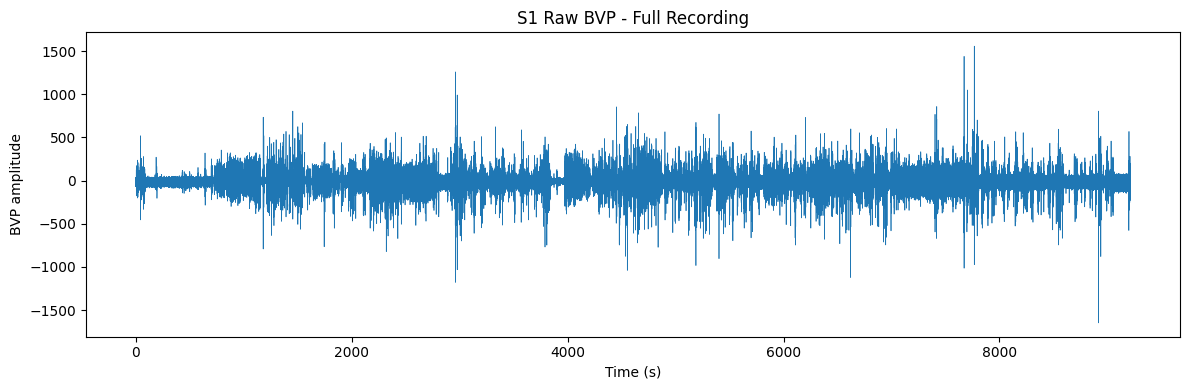

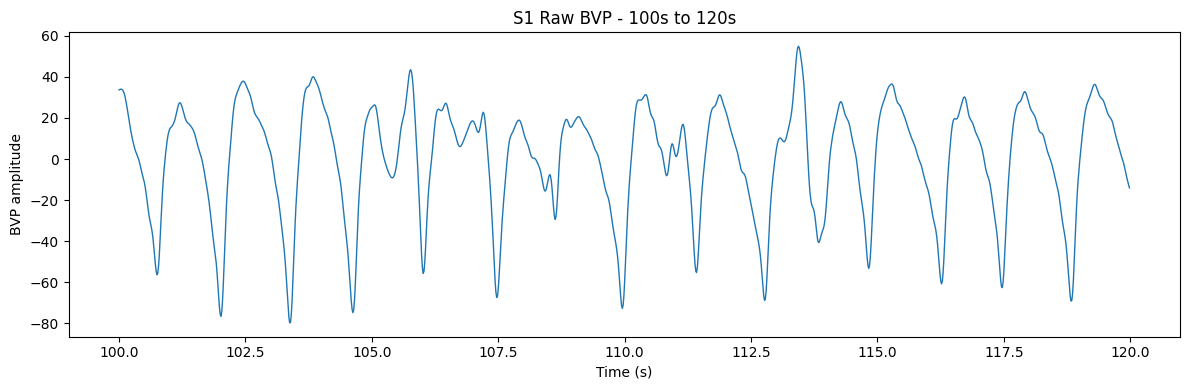

In [28]:
# PHASE 2.1 - RAW BVP VISUALIZATION

bvp_1d = bvp_signal.reshape(-1)

time_s = (
    np.arange(len(bvp_1d))
    / CONFIG["fs"]
)

print("BVP samples :", len(bvp_1d))
print(
    "Duration    :",
    round(len(bvp_1d) / CONFIG["fs"], 2),
    "seconds"
)
print("Minimum     :", bvp_1d.min())
print("Maximum     :", bvp_1d.max())
print("Mean        :", bvp_1d.mean())
print("Std         :", bvp_1d.std())


# Full recording
plt.figure(figsize=(12, 4))

plt.plot(
    time_s,
    bvp_1d,
    linewidth=0.5
)

plt.xlabel("Time (s)")
plt.ylabel("BVP amplitude")
plt.title("S1 Raw BVP - Full Recording")

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "s1-raw-bvp-full.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# Zoomed segment
zoom_start_s = 100
zoom_duration_s = 20

start_idx = int(
    zoom_start_s * CONFIG["fs"]
)

end_idx = int(
    (zoom_start_s + zoom_duration_s)
    * CONFIG["fs"]
)

plt.figure(figsize=(12, 4))

plt.plot(
    time_s[start_idx:end_idx],
    bvp_1d[start_idx:end_idx],
    linewidth=1
)

plt.xlabel("Time (s)")
plt.ylabel("BVP amplitude")
plt.title(
    f"S1 Raw BVP - "
    f"{zoom_start_s}s to "
    f"{zoom_start_s + zoom_duration_s}s"
)

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "s1-raw-bvp-zoom.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


,label,activity,count,percent
0,1,BASELINE,36580,9.69
1,2,STAIRS,25952,6.87
2,3,SOCCER,18516,4.90
3,4,CYCLING,27832,7.37
4,5,DRIVING,54748,14.50
5,6,LUNCH,108412,28.71
6,7,WALKING,37564,9.95
7,8,WORKING,68020,18.01


Total task samples : 377624
Raw label 0 samples: 140332
Class imbalance ratio: 5.86


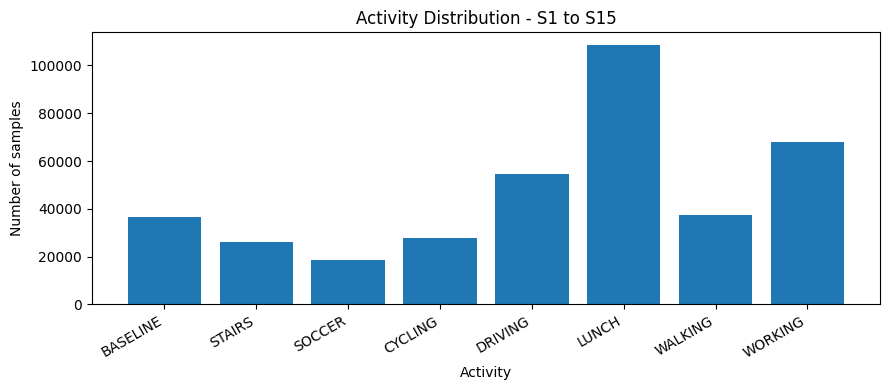

In [29]:
# PHASE 2.2 - ACTIVITY DISTRIBUTION

label_counts = {
    label: 0
    for label in range(
        1,
        CONFIG["num_classes"] + 1
    )
}

label_zero_count = 0

for subject_id in CONFIG["subjects"]:
    pkl_path = (
        DATA_ROOT
        / subject_id
        / f"{subject_id}.pkl"
    )

    with open(pkl_path, "rb") as f:
        try:
            data = pickle.load(f)
        except UnicodeDecodeError:
            f.seek(0)
            data = pickle.load(
                f,
                encoding="latin1"
            )

    activity = np.asarray(
        data["activity"]
    ).reshape(-1)

    activity = activity[
        np.isfinite(activity)
    ]

    labels, counts = np.unique(
        activity,
        return_counts=True
    )

    for label, count in zip(
        labels,
        counts
    ):
        label = int(label)
        count = int(count)

        if label == 0:
            label_zero_count += count

        elif label in label_counts:
            label_counts[label] += count

    del data, activity
    gc.collect()


label_to_activity = {
    i + 1: name
    for i, name in enumerate(task_activities)
}

activity_distribution = pd.DataFrame({
    "label": list(label_counts.keys()),
    "activity": [
        label_to_activity.get(
            label,
            f"Class {label}"
        )
        for label in label_counts
    ],
    "count": list(label_counts.values())
})

total_task_samples = (
    activity_distribution["count"].sum()
)

activity_distribution["percent"] = (
    activity_distribution["count"]
    / total_task_samples
    * 100
).round(2)

display(activity_distribution)

print(
    "Total task samples :",
    total_task_samples
)

print(
    "Raw label 0 samples:",
    label_zero_count
)

nonzero_counts = activity_distribution.loc[
    activity_distribution["count"] > 0,
    "count"
]

imbalance_ratio = (
    nonzero_counts.max()
    / nonzero_counts.min()
)

print(
    "Class imbalance ratio:",
    round(imbalance_ratio, 2)
)


plt.figure(figsize=(9, 4))

plt.bar(
    activity_distribution["activity"],
    activity_distribution["count"]
)

plt.xlabel("Activity")
plt.ylabel("Number of samples")
plt.title("Activity Distribution - S1 to S15")

plt.xticks(
    rotation=30,
    ha="right"
)

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "activity-distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


In [30]:
# PHASE 2.3 - SIGNAL QUALITY CHECK

quality_rows = []

flat_threshold_samples = int(
    2 * CONFIG["fs"]
)

for subject_id in CONFIG["subjects"]:
    pkl_path = (
        DATA_ROOT
        / subject_id
        / f"{subject_id}.pkl"
    )

    with open(pkl_path, "rb") as f:
        try:
            data = pickle.load(f)
        except UnicodeDecodeError:
            f.seek(0)
            data = pickle.load(
                f,
                encoding="latin1"
            )

    bvp = np.asarray(
        data["signal"]["wrist"]["BVP"]
    ).reshape(-1)

    finite_mask = np.isfinite(bvp)
    finite_bvp = bvp[finite_mask]

    nan_count = int(
        np.isnan(bvp).sum()
    )

    inf_count = int(
        np.isinf(bvp).sum()
    )

    # Detect longest sequence of unchanged samples
    if len(finite_bvp) > 1:
        same_value = np.isclose(
            np.diff(finite_bvp),
            0.0,
            atol=1e-12
        )

        longest_flat = 0
        current_flat = 0

        for is_flat in same_value:
            if is_flat:
                current_flat += 1
                longest_flat = max(
                    longest_flat,
                    current_flat
                )
            else:
                current_flat = 0

        longest_flat_samples = (
            longest_flat + 1
            if longest_flat > 0
            else 0
        )

    else:
        longest_flat_samples = 0

    quality_rows.append({
        "subject": subject_id,
        "samples": len(bvp),
        "nan_count": nan_count,
        "inf_count": inf_count,
        "mean": (
            finite_bvp.mean()
            if len(finite_bvp) > 0
            else np.nan
        ),
        "std": (
            finite_bvp.std()
            if len(finite_bvp) > 0
            else np.nan
        ),
        "min": (
            finite_bvp.min()
            if len(finite_bvp) > 0
            else np.nan
        ),
        "max": (
            finite_bvp.max()
            if len(finite_bvp) > 0
            else np.nan
        ),
        "p0.1": (
            np.percentile(
                finite_bvp,
                0.1
            )
            if len(finite_bvp) > 0
            else np.nan
        ),
        "p99.9": (
            np.percentile(
                finite_bvp,
                99.9
            )
            if len(finite_bvp) > 0
            else np.nan
        ),
        "longest_flat_s": (
            longest_flat_samples
            / CONFIG["fs"]
        )
    })

    del data, bvp, finite_bvp
    gc.collect()


signal_quality = pd.DataFrame(
    quality_rows
)

display(signal_quality)

print(
    "Total NaN:",
    signal_quality["nan_count"].sum()
)

print(
    "Total Inf:",
    signal_quality["inf_count"].sum()
)

print(
    "Subjects with flat segment >= 2 s:",
    signal_quality.loc[
        signal_quality["longest_flat_s"] >= 2,
        "subject"
    ].tolist()
)


,subject,samples,nan_count,inf_count,mean,std,min,max,p0.1,p99.9,longest_flat_s
0,S1,589568,0,0,-0.002307,97.138604,-1647.39,1557.58,-548.40124,477.36382,0.046875
1,S2,525120,0,0,-0.000448,37.960072,-648.58,482.77,-231.06025,199.44643,0.046875
2,S3,559424,0,0,-0.000328,69.975824,-1191.30,812.59,-406.48154,347.02232,0.046875
3,S4,585600,0,0,-0.004212,59.746963,-1019.53,937.16,-361.43233,343.76802,0.062500
4,S5,595520,0,0,-0.000606,103.808243,-890.32,1247.24,-571.38835,440.71481,0.031250
5,S6,336000,0,0,0.007230,83.513768,-1118.50,610.55,-454.91014,354.24005,0.031250
6,S7,597952,0,0,0.000802,60.293293,-776.77,460.78,-314.10735,236.98980,0.046875
7,S8,517120,0,0,0.000990,53.657715,-943.93,874.93,-412.58620,356.83787,0.062500
8,S9,547840,0,0,-0.002241,97.253571,-1608.31,1841.26,-655.59771,636.89186,0.046875
9,S10,681472,0,0,0.001526,58.700685,-1025.09,837.19,-390.10232,294.49877,0.046875


Total NaN: 0
Total Inf: 0
Subjects with flat segment >= 2 s: []


# Phase 2 – Kết luận

EDA cho thấy BVP thô có thể tiếp tục sử dụng cho pipeline chính mà không cần thêm bộ lọc số.

Kết quả nổi bật:

- S1 có **589,568 mẫu**, tương đương **9,212 giây**;
- không có **NaN** hoặc **Inf** trong S1–S15;
- không có subject nào xuất hiện đoạn phẳng kéo dài từ **2 giây** trở lên;
- phân bố activity không cân bằng hoàn toàn;
- `LUNCH` có nhiều mẫu nhất (**108,412; 28.71%**);
- `SOCCER` có ít mẫu nhất (**18,516; 4.90%**);
- tỷ lệ mất cân bằng lớn nhất/nhỏ nhất khoảng **5.86 lần**;
- raw label `0` có **140,332 mẫu** và được xem là vùng ngoài tám task chính.

Theo đề cương, các extreme values không bị tự động xóa và thí nghiệm chính không dùng class weighting, resampling hoặc band-pass filter.

# Phase 3 – Preprocessing theo đề cương M6

Quy trình chính:

1. đọc BVP và `activity` đồng bộ theo từng subject;
2. kiểm tra tỷ lệ BVP/activity;
3. khóa split theo subject;
4. giữ mã nhãn gốc trong dữ liệu trung gian;
5. chỉ giữ cửa sổ 8 giây khi toàn bộ nhãn thuộc cùng một activity hợp lệ;
6. không xóa đoạn label 0 rồi nối tín hiệu lại;
7. tính `μ_train`, `σ_train` **chỉ từ các điểm Train thuộc miền dữ liệu được giữ, mỗi điểm thời gian tính một lần**;
8. áp dụng cùng `μ_train`, `σ_train` cho Train/Validation/Test;
9. remap raw labels 1–8 → model labels 0–7 khi tạo dữ liệu mạng;
10. lưu `split.json`, `label_map.json`, scaler và thống kê preprocessing.

Không dùng band-pass filter trong pipeline chính.


In [31]:
# PHASE 3.1 - ALIGNMENT, SPLIT AND LABEL MAP

def load_pickle(subject_id):
    pkl_path = (
        DATA_ROOT
        / subject_id
        / f"{subject_id}.pkl"
    )

    with open(pkl_path, "rb") as f:
        try:
            data = pickle.load(f)
        except UnicodeDecodeError:
            f.seek(0)
            data = pickle.load(
                f,
                encoding="latin1"
            )

    return data


def align_activity_to_bvp(
    activity,
    bvp_length
):
    activity = np.asarray(
        activity
    ).reshape(-1)

    if len(activity) == 0:
        raise ValueError(
            "Activity array is empty."
        )

    ratio = bvp_length / len(activity)

    if not np.isclose(
        ratio,
        round(ratio)
    ):
        raise ValueError(
            f"BVP/activity ratio is not integer: {ratio}"
        )

    repeat_factor = int(
        round(ratio)
    )

    aligned = np.repeat(
        activity,
        repeat_factor
    )

    if len(aligned) != bvp_length:
        raise ValueError(
            "Aligned label length does not match BVP length."
        )

    return aligned, repeat_factor


alignment_rows = []

for subject_id in CONFIG["subjects"]:
    data = load_pickle(subject_id)

    bvp = np.asarray(
        data["signal"]["wrist"]["BVP"]
    ).reshape(-1)

    activity = np.asarray(
        data["activity"]
    ).reshape(-1)

    aligned, repeat_factor = (
        align_activity_to_bvp(
            activity,
            len(bvp)
        )
    )

    alignment_rows.append({
        "subject": subject_id,
        "bvp_samples": len(bvp),
        "activity_samples": len(activity),
        "ratio": (
            len(bvp) / len(activity)
        ),
        "repeat_factor": repeat_factor,
        "alignment_length_diff": (
            len(aligned) - len(bvp)
        )
    })

    del data, bvp, activity, aligned
    gc.collect()


alignment_check = pd.DataFrame(
    alignment_rows
)

alignment_check.to_csv(
    RESULTS_DIR
    / "alignment-check.csv",
    index=False
)

display(alignment_check)

assert (
    alignment_check[
        "alignment_length_diff"
    ] == 0
).all()

assert (
    alignment_check[
        "repeat_factor"
    ] == 16
).all()


split_spec = {
    "train": CONFIG["train_subjects"],
    "validation": CONFIG["val_subjects"],
    "test": CONFIG["test_subjects"]
}

with open(
    CONFIG_DIR / "split.json",
    "w",
    encoding="utf-8"
) as f:
    json.dump(
        split_spec,
        f,
        indent=2,
        ensure_ascii=False
    )


if len(task_activities) != CONFIG["num_classes"]:
    raise ValueError(
        "Không xác định được đúng 8 activity từ metadata."
    )


label_map = {
    str(raw_label): {
        "model_label": raw_label - 1,
        "activity": task_activities[
            raw_label - 1
        ]
    }
    for raw_label in range(
        1,
        CONFIG["num_classes"] + 1
    )
}

with open(
    CONFIG_DIR / "label_map.json",
    "w",
    encoding="utf-8"
) as f:
    json.dump(
        label_map,
        f,
        indent=2,
        ensure_ascii=False
    )


print(
    "Unique alignment ratios:",
    sorted(
        alignment_check["ratio"]
        .unique()
        .tolist()
    )
)

print(
    "split.json saved:",
    CONFIG_DIR / "split.json"
)

print(
    "label_map.json saved:",
    CONFIG_DIR / "label_map.json"
)

print(
    "Alignment and metadata checks: PASSED"
)


,subject,bvp_samples,activity_samples,ratio,repeat_factor,alignment_length_diff
0,S1,589568,36848,16.0,16,0
1,S2,525120,32820,16.0,16,0
2,S3,559424,34964,16.0,16,0
3,S4,585600,36600,16.0,16,0
4,S5,595520,37220,16.0,16,0
5,S6,336000,21000,16.0,16,0
6,S7,597952,37372,16.0,16,0
7,S8,517120,32320,16.0,16,0
8,S9,547840,34240,16.0,16,0
9,S10,681472,42592,16.0,16,0


Unique alignment ratios: [16.0]
split.json saved: d:\IOT_AI\Dual_Task_Autoencoder\configs\split.json
label_map.json saved: d:\IOT_AI\Dual_Task_Autoencoder\configs\label_map.json
Alignment and metadata checks: PASSED


In [32]:
# PHASE 3.2 - VALID WINDOWS AND TRAIN-ONLY SCALER

WINDOW_SIZE = CONFIG["window_size"]
STRIDE = CONFIG["stride"]


def scan_valid_windows(
    bvp,
    labels_aligned
):
    starts = []
    model_labels = []

    candidate_windows = 0
    rejected_nonfinite = 0
    rejected_invalid_label = 0
    rejected_transition = 0

    union_kept_mask = np.zeros(
        len(bvp),
        dtype=bool
    )

    for start in range(
        0,
        len(bvp) - WINDOW_SIZE + 1,
        STRIDE
    ):
        end = start + WINDOW_SIZE
        candidate_windows += 1

        xw = bvp[start:end]
        yw = labels_aligned[start:end]

        if not np.isfinite(xw).all():
            rejected_nonfinite += 1
            continue

        if not np.isfinite(yw).all():
            rejected_invalid_label += 1
            continue

        if (
            (yw < 1).any()
            or (
                yw
                > CONFIG["num_classes"]
            ).any()
        ):
            rejected_invalid_label += 1
            continue

        unique_labels = np.unique(yw)

        if len(unique_labels) != 1:
            rejected_transition += 1
            continue

        raw_label = int(
            unique_labels[0]
        )

        starts.append(start)
        model_labels.append(
            raw_label - 1
        )

        union_kept_mask[
            start:end
        ] = True

    summary = {
        "candidate_windows": candidate_windows,
        "kept_windows": len(starts),
        "rejected_nonfinite": rejected_nonfinite,
        "rejected_invalid_label": rejected_invalid_label,
        "rejected_transition": rejected_transition
    }

    return (
        np.asarray(
            starts,
            dtype=np.int64
        ),
        np.asarray(
            model_labels,
            dtype=np.int64
        ),
        union_kept_mask,
        summary
    )


valid_window_index = {}
subject_summary_rows = []
subject_class_rows = []

train_sum = 0.0
train_sumsq = 0.0
train_count = 0


for subject_id in CONFIG["subjects"]:

    data = load_pickle(subject_id)

    bvp = np.asarray(
        data["signal"]["wrist"]["BVP"],
        dtype=np.float64
    ).reshape(-1)

    activity = np.asarray(
        data["activity"]
    ).reshape(-1)

    labels_aligned, repeat_factor = (
        align_activity_to_bvp(
            activity,
            len(bvp)
        )
    )

    (
        starts,
        model_labels,
        union_kept_mask,
        summary
    ) = scan_valid_windows(
        bvp,
        labels_aligned
    )

    valid_window_index[
        subject_id
    ] = {
        "starts": starts,
        "labels": model_labels
    }

    subject_summary_rows.append({
        "subject": subject_id,
        "duration_s": (
            len(bvp) / CONFIG["fs"]
        ),
        "bvp_samples": len(bvp),
        "activity_samples": len(activity),
        "repeat_factor": repeat_factor,
        "alignment_length_diff": (
            len(labels_aligned) - len(bvp)
        ),
        "nonfinite_bvp_samples": int(
            (~np.isfinite(bvp)).sum()
        ),
        "unique_kept_seconds": (
            union_kept_mask.sum()
            / CONFIG["fs"]
        ),
        **summary
    })

    for class_id in range(
        CONFIG["num_classes"]
    ):
        raw_label = class_id + 1

        class_point_mask = (
            union_kept_mask
            & (labels_aligned == raw_label)
        )

        subject_class_rows.append({
            "subject": subject_id,
            "class_id": class_id,
            "raw_label": raw_label,
            "activity": task_activities[
                class_id
            ],
            "kept_windows": int(
                np.sum(
                    model_labels
                    == class_id
                )
            ),
            "unique_duration_s": (
                class_point_mask.sum()
                / CONFIG["fs"]
            )
        })

    if subject_id in CONFIG[
        "train_subjects"
    ]:
        train_values = bvp[
            union_kept_mask
        ]

        if not np.isfinite(
            train_values
        ).all():
            raise ValueError(
                f"Non-finite Train values in {subject_id}"
            )

        train_sum += train_values.sum(
            dtype=np.float64
        )

        train_sumsq += np.square(
            train_values,
            dtype=np.float64
        ).sum(
            dtype=np.float64
        )

        train_count += len(
            train_values
        )

    del (
        data,
        bvp,
        activity,
        labels_aligned,
        union_kept_mask
    )

    gc.collect()


subject_window_summary = pd.DataFrame(
    subject_summary_rows
)

window_counts_by_subject_class = pd.DataFrame(
    subject_class_rows
)


if train_count == 0:
    raise ValueError(
        "Không có điểm Train hợp lệ để tính scaler."
    )


mu_train = (
    train_sum
    / train_count
)

variance_train = (
    train_sumsq
    / train_count
    - mu_train ** 2
)

sigma_train = math.sqrt(
    max(
        variance_train,
        0.0
    )
)


if (
    not np.isfinite(mu_train)
    or not np.isfinite(sigma_train)
    or sigma_train < 1e-12
):
    raise ValueError(
        "Scaler Train không hợp lệ."
    )


scaler = {
    "mean": float(mu_train),
    "std": float(sigma_train),
    "n_unique_train_points": int(
        train_count
    ),
    "source": (
        "Unique time points covered by kept Train windows"
    )
}


with open(
    CONFIG_DIR / "scaler.json",
    "w",
    encoding="utf-8"
) as f:
    json.dump(
        scaler,
        f,
        indent=2
    )


subject_window_summary.to_csv(
    RESULTS_DIR
    / "preprocessing-by-subject.csv",
    index=False
)

window_counts_by_subject_class.to_csv(
    RESULTS_DIR
    / "window-counts-by-subject-class.csv",
    index=False
)


display(subject_window_summary)

display(
    window_counts_by_subject_class.head(
        16
    )
)

print("\nTrain scaler:")
print("mu_train    :", mu_train)
print("sigma_train :", sigma_train)
print(
    "Unique Train points:",
    train_count
)

print(
    "\nMain digital filter:",
    CONFIG["main_filter"]
)

print(
    "Train-only scaler check: PASSED"
)


,subject,duration_s,bvp_samples,activity_samples,repeat_factor,alignment_length_diff,nonfinite_bvp_samples,unique_kept_seconds,candidate_windows,kept_windows,rejected_nonfinite,rejected_invalid_label,rejected_transition
0,S1,9212.0,589568,36848,16,0,0,6908.0,2302,1719,0,583,0
1,S2,8205.0,525120,32820,16,0,0,5644.0,2050,1403,0,647,0
2,S3,8741.0,559424,34964,16,0,0,6688.0,2184,1664,0,520,0
3,S4,9150.0,585600,36600,16,0,0,6608.0,2286,1644,0,642,0
4,S5,9305.0,595520,37220,16,0,0,6708.0,2325,1669,0,656,0
5,S6,5250.0,336000,21000,16,0,0,2932.0,1311,728,0,583,0
6,S7,9343.0,597952,37372,16,0,0,7108.0,2334,1769,0,565,0
7,S8,8080.0,517120,32320,16,0,0,5980.0,2019,1487,0,532,0
8,S9,8560.0,547840,34240,16,0,0,6520.0,2139,1622,0,517,0
9,S10,10648.0,681472,42592,16,0,0,7088.0,2661,1764,0,897,0


,subject,class_id,raw_label,activity,kept_windows,unique_duration_s
0,S1,0,1,BASELINE,173,696.0
1,S1,1,2,STAIRS,70,284.0
2,S1,2,3,SOCCER,84,340.0
3,S1,3,4,CYCLING,101,408.0
4,S1,4,5,DRIVING,221,888.0
5,S1,5,6,LUNCH,587,2352.0
6,S1,6,7,WALKING,187,752.0
7,S1,7,8,WORKING,296,1188.0
8,S2,0,1,BASELINE,148,596.0
9,S2,1,2,STAIRS,65,264.0



Train scaler:
mu_train    : 0.004277964825032665
sigma_train : 76.028651766159
Unique Train points: 3526144

Main digital filter: None
Train-only scaler check: PASSED


In [33]:
# PHASE 3.3 - BUILD NORMALIZED WINDOWS

split_data = {
    "train": {
        "X": [],
        "y": [],
        "subject": [],
        "subject_idx": [],
        "start_sample": []
    },
    "val": {
        "X": [],
        "y": [],
        "subject": [],
        "subject_idx": [],
        "start_sample": []
    },
    "test": {
        "X": [],
        "y": [],
        "subject": [],
        "subject_idx": [],
        "start_sample": []
    }
}


subject_to_idx = {
    subject_id: idx
    for idx, subject_id
    in enumerate(
        CONFIG["subjects"]
    )
}


for subject_id in CONFIG["subjects"]:

    data = load_pickle(subject_id)

    bvp = np.asarray(
        data["signal"]["wrist"]["BVP"],
        dtype=np.float64
    ).reshape(-1)

    starts = valid_window_index[
        subject_id
    ]["starts"]

    labels = valid_window_index[
        subject_id
    ]["labels"]

    X_subject = np.empty(
        (
            len(starts),
            WINDOW_SIZE
        ),
        dtype=np.float32
    )

    for i, start in enumerate(
        starts
    ):
        end = start + WINDOW_SIZE

        X_subject[i] = (
            (
                bvp[start:end]
                - mu_train
            )
            / sigma_train
        ).astype(
            np.float32
        )

    if subject_id in CONFIG[
        "train_subjects"
    ]:
        split_name = "train"
    elif subject_id in CONFIG[
        "val_subjects"
    ]:
        split_name = "val"
    elif subject_id in CONFIG[
        "test_subjects"
    ]:
        split_name = "test"
    else:
        raise ValueError(
            f"Subject not assigned: {subject_id}"
        )

    split_data[
        split_name
    ]["X"].append(
        X_subject
    )

    split_data[
        split_name
    ]["y"].append(
        labels
    )

    split_data[
        split_name
    ]["subject"].extend(
        [subject_id] * len(starts)
    )

    split_data[
        split_name
    ]["subject_idx"].extend(
        [
            subject_to_idx[
                subject_id
            ]
        ] * len(starts)
    )

    split_data[
        split_name
    ]["start_sample"].extend(
        starts.tolist()
    )

    del data, bvp, X_subject
    gc.collect()


for split_name in [
    "train",
    "val",
    "test"
]:
    split_data[
        split_name
    ]["X"] = np.concatenate(
        split_data[
            split_name
        ]["X"],
        axis=0
    )

    split_data[
        split_name
    ]["y"] = np.concatenate(
        split_data[
            split_name
        ]["y"],
        axis=0
    ).astype(
        np.int64
    )

    split_data[
        split_name
    ]["subject"] = np.asarray(
        split_data[
            split_name
        ]["subject"]
    )

    split_data[
        split_name
    ]["subject_idx"] = np.asarray(
        split_data[
            split_name
        ]["subject_idx"],
        dtype=np.int64
    )

    split_data[
        split_name
    ]["start_sample"] = np.asarray(
        split_data[
            split_name
        ]["start_sample"],
        dtype=np.int64
    )


# Save preprocessed arrays
np.savez_compressed(
    PROCESSED_DIR
    / "m6-main-preprocessed.npz",

    X_train=split_data["train"]["X"],
    y_train=split_data["train"]["y"],
    subject_train=split_data["train"]["subject"],
    subject_idx_train=split_data["train"]["subject_idx"],
    start_train=split_data["train"]["start_sample"],

    X_val=split_data["val"]["X"],
    y_val=split_data["val"]["y"],
    subject_val=split_data["val"]["subject"],
    subject_idx_val=split_data["val"]["subject_idx"],
    start_val=split_data["val"]["start_sample"],

    X_test=split_data["test"]["X"],
    y_test=split_data["test"]["y"],
    subject_test=split_data["test"]["subject"],
    subject_idx_test=split_data["test"]["subject_idx"],
    start_test=split_data["test"]["start_sample"]
)


split_rows = []

for split_name in [
    "train",
    "val",
    "test"
]:
    X = split_data[
        split_name
    ]["X"]

    y = split_data[
        split_name
    ]["y"]

    assert np.isfinite(X).all()
    assert X.shape[1] == WINDOW_SIZE

    split_rows.append({
        "split": split_name,
        "windows": len(y),
        "subjects": len(
            np.unique(
                split_data[
                    split_name
                ]["subject"]
            )
        ),
        "classes_present": sorted(
            np.unique(y).tolist()
        )
    })


split_window_summary = pd.DataFrame(
    split_rows
)

split_window_summary.to_csv(
    RESULTS_DIR
    / "split-window-summary.csv",
    index=False
)

display(split_window_summary)


train_classes = set(
    np.unique(
        split_data["train"]["y"]
    ).tolist()
)

assert train_classes == set(
    range(
        CONFIG["num_classes"]
    )
), (
    "Train thiếu ít nhất một class. "
    "Phải xử lý lại dữ liệu trước khi chạy đối chứng."
)


assert set(
    CONFIG["train_subjects"]
).isdisjoint(
    CONFIG["val_subjects"]
)

assert set(
    CONFIG["train_subjects"]
).isdisjoint(
    CONFIG["test_subjects"]
)

assert set(
    CONFIG["val_subjects"]
).isdisjoint(
    CONFIG["test_subjects"]
)


print(
    "Preprocessed file:",
    PROCESSED_DIR
    / "m6-main-preprocessed.npz"
)

print(
    "Windowing, normalization and split checks: PASSED"
)


,split,windows,subjects,classes_present
0,train,13705,9,"[0, 1, 2, 3, 4, 5, 6, 7]"
1,val,4967,3,"[0, 1, 2, 3, 4, 5, 6, 7]"
2,test,4707,3,"[0, 1, 2, 3, 4, 5, 6, 7]"


Preprocessed file: d:\IOT_AI\Dual_Task_Autoencoder\processed\m6-main-preprocessed.npz
Windowing, normalization and split checks: PASSED


activity,BASELINE,CYCLING,DRIVING,LUNCH,SOCCER,STAIRS,WALKING,WORKING
subject,,,,,,,,
S1,173,101,221,587,84,70,187,296
S10,148,120,233,519,75,115,269,285
S11,148,121,213,600,79,112,162,303
S12,149,118,221,363,68,119,131,296
S13,149,122,223,505,71,122,175,304
S14,150,124,236,431,80,112,152,299
S15,151,99,194,358,86,102,163,299
S2,148,95,228,303,74,65,170,320
S3,148,92,225,538,71,107,183,300


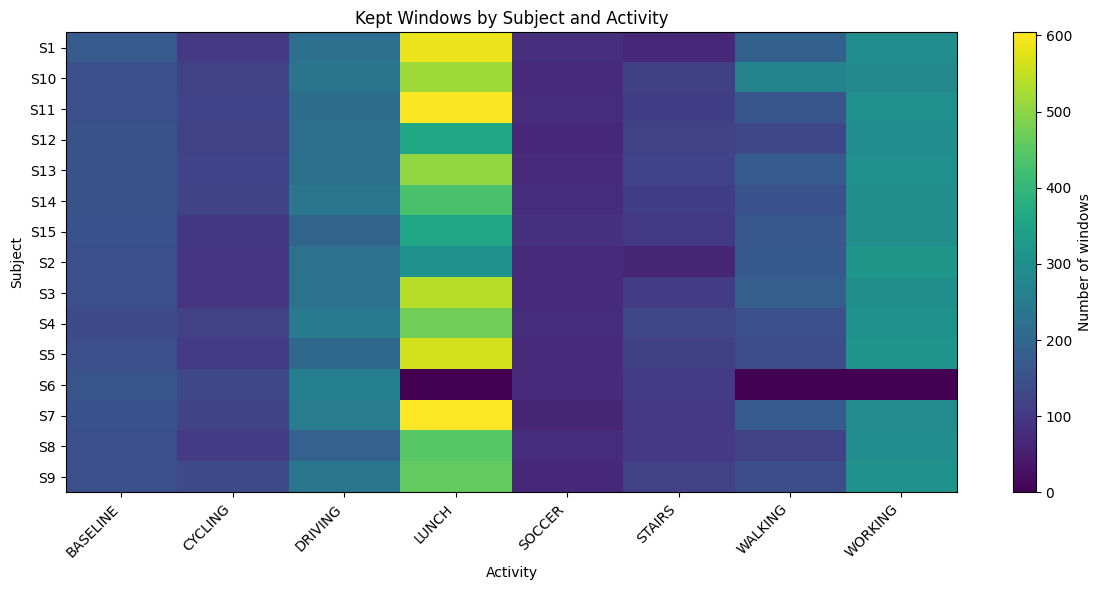

,activity,kept_windows
0,BASELINE,2257
1,CYCLING,1711
2,DRIVING,3394
3,LUNCH,6748
4,SOCCER,1128
5,STAIRS,1593
6,WALKING,2324
7,WORKING,4224


In [34]:
# PHASE 3.4 - WINDOW DISTRIBUTION BY SUBJECT AND CLASS

window_pivot = (
    window_counts_by_subject_class
    .pivot(
        index="subject",
        columns="activity",
        values="kept_windows"
    )
    .fillna(0)
)

display(window_pivot)


plt.figure(
    figsize=(12, 6)
)

plt.imshow(
    window_pivot.values,
    aspect="auto"
)

plt.xticks(
    range(
        len(
            window_pivot.columns
        )
    ),
    window_pivot.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(
        len(
            window_pivot.index
        )
    ),
    window_pivot.index
)

plt.xlabel("Activity")
plt.ylabel("Subject")
plt.title(
    "Kept Windows by Subject and Activity"
)

plt.colorbar(
    label="Number of windows"
)

plt.tight_layout()

plt.savefig(
    FIGURE_DIR
    / "window-distribution-subject-class.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


overall_window_counts = (
    window_counts_by_subject_class
    .groupby(
        "activity",
        as_index=False
    )["kept_windows"]
    .sum()
)

display(
    overall_window_counts
)


# Phase 3 – Kết luận

Preprocessing đã được thực hiện đúng theo đề cương M6.

Các kiểm tra chính:

- BVP/activity của cả 15 subject có tỷ lệ **16:1**, tương ứng 64 Hz và 4 Hz;
- không dùng band-pass filter;
- chỉ giữ window 8 giây có đúng một activity hợp lệ;
- không nối các đoạn tín hiệu sau khi loại vùng label `0`;
- raw labels `1–8` được remap sang class IDs `0–7`;
- scaler chỉ được học từ Train trên các điểm thời gian hợp lệ và mỗi điểm chỉ được tính một lần.

Scaler Train thu được:

- `mu_train = 0.004278`;
- `sigma_train = 76.028652`;
- số điểm Train duy nhất dùng để tính scaler: **3,526,144**.

Số window cuối cùng:

- Train: **13,705**;
- Validation: **4,967**;
- Test: **4,707**.

Cả ba split đều có đủ 8 class. Các file `split.json`, `label_map.json`, `scaler.json`, dữ liệu preprocessing và bảng thống kê theo subject/class đã được lưu thành công.

# Phase 4 – PyTorch Dataset & DataLoader

Mỗi mẫu đưa vào mạng có shape `[1, 512]`.

Dataset giữ thêm metadata:

- `subject_idx`;
- `start_sample`.

Metadata này không đi vào mạng nhưng cần để:

- tổng hợp metric theo từng subject;
- lưu kết quả từng window;
- chọn checkpoint đúng theo Validation subject-level Macro-F1/MSE.


In [35]:
# PHASE 4.1 - DATASET AND DATALOADER

class PPGWindowDataset(Dataset):

    def __init__(
        self,
        X,
        y,
        subject_idx,
        start_sample
    ):
        self.X = np.asarray(
            X,
            dtype=np.float32
        )

        self.y = np.asarray(
            y,
            dtype=np.int64
        )

        self.subject_idx = np.asarray(
            subject_idx,
            dtype=np.int64
        )

        self.start_sample = np.asarray(
            start_sample,
            dtype=np.int64
        )

        n = len(self.y)

        if not (
            len(self.X)
            == n
            == len(
                self.subject_idx
            )
            == len(
                self.start_sample
            )
        ):
            raise ValueError(
                "Dataset arrays must have the same length."
            )

    def __len__(self):
        return len(self.y)

    def __getitem__(
        self,
        index
    ):
        x = torch.from_numpy(
            self.X[index]
        ).unsqueeze(0)

        y = torch.tensor(
            self.y[index],
            dtype=torch.long
        )

        subject_idx = torch.tensor(
            self.subject_idx[index],
            dtype=torch.long
        )

        start_sample = torch.tensor(
            self.start_sample[index],
            dtype=torch.long
        )

        return (
            x,
            y,
            subject_idx,
            start_sample
        )


def make_dataset(split_name):
    data = split_data[
        split_name
    ]

    return PPGWindowDataset(
        data["X"],
        data["y"],
        data["subject_idx"],
        data["start_sample"]
    )


train_dataset = make_dataset(
    "train"
)

val_dataset = make_dataset(
    "val"
)

test_dataset = make_dataset(
    "test"
)


def make_dataloaders(seed):
    generator = torch.Generator()
    generator.manual_seed(seed)

    train_loader = DataLoader(
        train_dataset,
        batch_size=CONFIG[
            "batch_size"
        ],
        shuffle=True,
        num_workers=0,
        pin_memory=torch.cuda.is_available(),
        generator=generator
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=CONFIG[
            "batch_size"
        ],
        shuffle=False,
        num_workers=0,
        pin_memory=torch.cuda.is_available()
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=CONFIG[
            "batch_size"
        ],
        shuffle=False,
        num_workers=0,
        pin_memory=torch.cuda.is_available()
    )

    return (
        train_loader,
        val_loader,
        test_loader
    )


train_loader, val_loader, test_loader = (
    make_dataloaders(
        CONFIG["seeds"][0]
    )
)


x_batch, y_batch, sid_batch, start_batch = (
    next(
        iter(
            train_loader
        )
    )
)


print(
    "Train/Val/Test sizes:",
    len(train_dataset),
    len(val_dataset),
    len(test_dataset)
)

print(
    "Batch X:",
    x_batch.shape,
    x_batch.dtype
)

print(
    "Batch y:",
    y_batch.shape,
    y_batch.dtype
)

print(
    "Metadata:",
    sid_batch.shape,
    start_batch.shape
)

assert x_batch.ndim == 3
assert x_batch.shape[1:] == (
    1,
    WINDOW_SIZE
)
assert x_batch.dtype == torch.float32
assert y_batch.dtype == torch.int64
assert torch.isfinite(
    x_batch
).all()

print(
    "Dataset and DataLoader checks: PASSED"
)


Train/Val/Test sizes: 13705 4967 4707
Batch X: torch.Size([64, 1, 512]) torch.float32
Batch y: torch.Size([64]) torch.int64
Metadata: torch.Size([64]) torch.Size([64])
Dataset and DataLoader checks: PASSED


# Phase 4 – Kết luận

PyTorch Dataset và DataLoader đã được tạo thành công.

- Train: **13,705 windows**;
- Validation: **4,967 windows**;
- Test: **4,707 windows**;
- input batch có shape **[64, 1, 512]** và dtype `float32`;
- label có dtype `int64`;
- metadata `subject_idx` và `start_sample` được giữ xuyên suốt pipeline.

Train DataLoader được shuffle theo seed, còn Validation/Test không shuffle. Metadata không đi vào mạng mà được dùng để tổng hợp metric theo subject và lưu kết quả từng window.

# Phase 5 – Model Architecture

Kiến trúc chính được khóa đúng theo đề cương.

## Shared encoder

- Conv1d 1→32, `k=7, s=2, p=3`, ReLU;
- Conv1d 32→64, `k=5, s=2, p=2`, ReLU;
- Conv1d 64→128, `k=3, s=2, p=1`, ReLU;
- **không BatchNorm**.

Output: `[B, 128, 64]`.

## Decoder

- ConvTranspose1d 128→64, `k=3, s=2, p=1, output_padding=1`;
- ConvTranspose1d 64→32, `k=5, s=2, p=2, output_padding=1`;
- ConvTranspose1d 32→1, `k=7, s=2, p=3, output_padding=1`.

## Classification head

GAP:

`AdaptiveAvgPool1d(1) → Linear(128,128) → ReLU → Dropout(0.2) → Linear(128,8)`

Flatten:

`Flatten → Linear(8192,128) → ReLU → Dropout(0.2) → Linear(128,8)`

GAP/Flatten chỉ nằm ở nhánh classification. Decoder nhận trực tiếp shared feature map `Z`.


In [36]:
# PHASE 5.1 - EXACT ENCODER AND DECODER

class PPGEncoder(nn.Module):

    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Conv1d(
                1,
                32,
                kernel_size=7,
                stride=2,
                padding=3
            ),
            nn.ReLU(),

            nn.Conv1d(
                32,
                64,
                kernel_size=5,
                stride=2,
                padding=2
            ),
            nn.ReLU(),

            nn.Conv1d(
                64,
                128,
                kernel_size=3,
                stride=2,
                padding=1
            ),
            nn.ReLU()
        )

    def forward(self, x):
        return self.net(x)


class PPGDecoder(nn.Module):

    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.ConvTranspose1d(
                128,
                64,
                kernel_size=3,
                stride=2,
                padding=1,
                output_padding=1
            ),
            nn.ReLU(),

            nn.ConvTranspose1d(
                64,
                32,
                kernel_size=5,
                stride=2,
                padding=2,
                output_padding=1
            ),
            nn.ReLU(),

            nn.ConvTranspose1d(
                32,
                1,
                kernel_size=7,
                stride=2,
                padding=3,
                output_padding=1
            )
        )

    def forward(self, z):
        return self.net(z)


encoder_test = PPGEncoder().to(
    device
)

decoder_test = PPGDecoder().to(
    device
)

x_test = x_batch[:4].to(
    device
)

with torch.no_grad():
    z_test = encoder_test(
        x_test
    )

    recon_test = decoder_test(
        z_test
    )


print(
    "Input:",
    tuple(
        x_test.shape
    )
)

print(
    "Z:",
    tuple(
        z_test.shape
    )
)

print(
    "Reconstruction:",
    tuple(
        recon_test.shape
    )
)


assert z_test.shape == (
    4,
    128,
    64
)

assert recon_test.shape == (
    4,
    1,
    512
)

print(
    "Encoder/decoder shape checks: PASSED"
)


Input: (4, 1, 512)
Z: (4, 128, 64)
Reconstruction: (4, 1, 512)
Encoder/decoder shape checks: PASSED


,model,parameters,expected_parameters,logits_shape,reconstruction_shape
0,MTL-GAP,87945,87945,"(4, 8)","(4, 1, 512)"
1,MTL-Flat,1120137,1120137,"(4, 8)","(4, 1, 512)"
2,CNN-GAP,52808,52808,"(4, 8)",None
3,CNN-Flat,1085000,1085000,"(4, 8)",None
4,AE,70401,70401,None,"(4, 1, 512)"


Exact architecture and parameter checks: PASSED


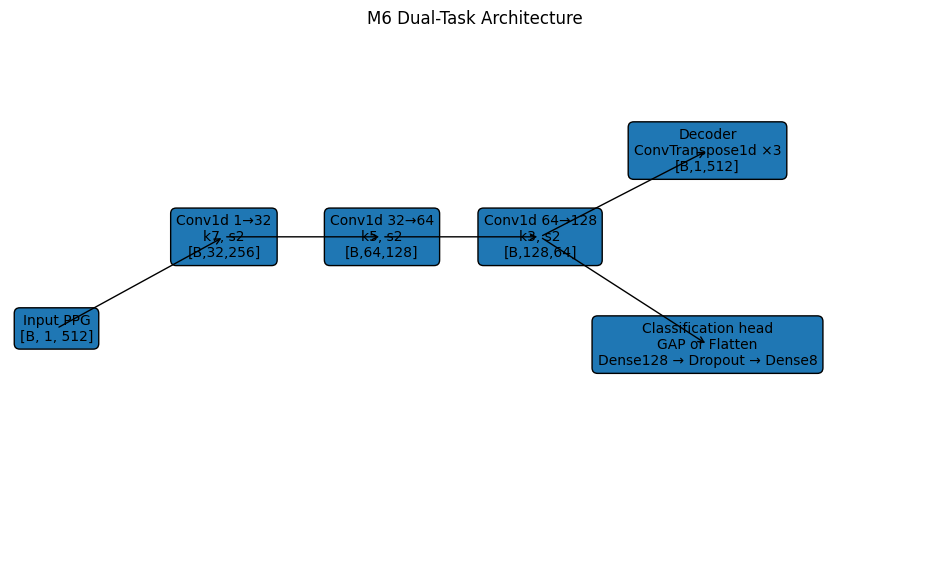

In [37]:
# PHASE 5.2 - FIVE REQUIRED MODEL CONFIGURATIONS

class ClassificationHead(nn.Module):

    def __init__(
        self,
        mode,
        num_classes
    ):
        super().__init__()

        if mode not in {
            "gap",
            "flat"
        }:
            raise ValueError(
                "mode must be gap or flat"
            )

        self.mode = mode

        if mode == "gap":
            self.feature = (
                nn.AdaptiveAvgPool1d(
                    1
                )
            )
            input_dim = 128
        else:
            self.feature = nn.Flatten(
                start_dim=1
            )
            input_dim = 8192

        self.hidden = nn.Linear(
            input_dim,
            CONFIG["hidden_dim"]
        )

        self.relu = nn.ReLU()

        self.dropout = nn.Dropout(
            CONFIG["dropout"]
        )

        self.output = nn.Linear(
            CONFIG["hidden_dim"],
            num_classes
        )

    def forward(self, z):
        h = self.feature(z)

        if self.mode == "gap":
            h = h.squeeze(-1)

        h = self.hidden(h)
        h = self.relu(h)
        h = self.dropout(h)

        return self.output(h)


class PPGClassifier(nn.Module):

    def __init__(
        self,
        mode,
        num_classes=8
    ):
        super().__init__()

        self.encoder = PPGEncoder()
        self.head = ClassificationHead(
            mode,
            num_classes
        )

    def forward(self, x):
        z = self.encoder(x)
        return self.head(z)


class PPGMultiTask(nn.Module):

    def __init__(
        self,
        mode,
        num_classes=8
    ):
        super().__init__()

        self.encoder = PPGEncoder()
        self.decoder = PPGDecoder()
        self.head = ClassificationHead(
            mode,
            num_classes
        )

    def forward(self, x):
        z = self.encoder(x)

        logits = self.head(z)
        reconstruction = self.decoder(z)

        return (
            logits,
            reconstruction
        )


class PPGAutoencoder(nn.Module):

    def __init__(self):
        super().__init__()

        self.encoder = PPGEncoder()
        self.decoder = PPGDecoder()

    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z)


def build_model(model_name):

    if model_name == "MTL-GAP":
        return PPGMultiTask(
            "gap",
            CONFIG["num_classes"]
        )

    if model_name == "MTL-Flat":
        return PPGMultiTask(
            "flat",
            CONFIG["num_classes"]
        )

    if model_name == "CNN-GAP":
        return PPGClassifier(
            "gap",
            CONFIG["num_classes"]
        )

    if model_name == "CNN-Flat":
        return PPGClassifier(
            "flat",
            CONFIG["num_classes"]
        )

    if model_name == "AE":
        return PPGAutoencoder()

    raise ValueError(
        f"Unknown model: {model_name}"
    )


def count_parameters(model):
    return sum(
        p.numel()
        for p in model.parameters()
        if p.requires_grad
    )


MODEL_NAMES = [
    "MTL-GAP",
    "MTL-Flat",
    "CNN-GAP",
    "CNN-Flat",
    "AE"
]


expected_parameters = {
    "MTL-GAP": 87945,
    "MTL-Flat": 1120137,
    "CNN-GAP": 52808,
    "CNN-Flat": 1085000,
    "AE": 70401
}


model_rows = []

for model_name in MODEL_NAMES:

    model = build_model(
        model_name
    ).to(device)

    model.eval()

    with torch.no_grad():
        output = model(
            x_test
        )

    if model_name.startswith(
        "MTL"
    ):
        logits, reconstruction = output
        logits_shape = tuple(
            logits.shape
        )
        reconstruction_shape = tuple(
            reconstruction.shape
        )

    elif model_name.startswith(
        "CNN"
    ):
        logits_shape = tuple(
            output.shape
        )
        reconstruction_shape = None

    else:
        logits_shape = None
        reconstruction_shape = tuple(
            output.shape
        )

    parameters = count_parameters(
        model
    )

    model_rows.append({
        "model": model_name,
        "parameters": parameters,
        "expected_parameters": expected_parameters[
            model_name
        ],
        "logits_shape": logits_shape,
        "reconstruction_shape": reconstruction_shape
    })

    assert (
        parameters
        == expected_parameters[
            model_name
        ]
    )

    del model

    if torch.cuda.is_available():
        torch.cuda.empty_cache()


model_summary = pd.DataFrame(
    model_rows
)

model_summary.to_csv(
    RESULTS_DIR
    / "model-parameter-summary.csv",
    index=False
)

display(model_summary)

print(
    "Exact architecture and parameter checks: PASSED"
)


# Architecture figure
fig, ax = plt.subplots(
    figsize=(12, 7)
)

ax.axis("off")

boxes = {
    "input": (0.05, 0.45, "Input PPG\n[B, 1, 512]"),
    "enc1": (0.23, 0.62, "Conv1d 1→32\nk7, s2\n[B,32,256]"),
    "enc2": (0.40, 0.62, "Conv1d 32→64\nk5, s2\n[B,64,128]"),
    "enc3": (0.57, 0.62, "Conv1d 64→128\nk3, s2\n[B,128,64]"),
    "decoder": (0.75, 0.78, "Decoder\nConvTranspose1d ×3\n[B,1,512]"),
    "head": (0.75, 0.42, "Classification head\nGAP or Flatten\nDense128 → Dropout → Dense8")
}

for key, (
    x,
    y,
    label
) in boxes.items():

    ax.text(
        x,
        y,
        label,
        ha="center",
        va="center",
        transform=ax.transAxes,
        bbox={
            "boxstyle": "round,pad=0.4"
        }
    )


arrows = [
    (
        boxes["input"][:2],
        boxes["enc1"][:2]
    ),
    (
        boxes["enc1"][:2],
        boxes["enc2"][:2]
    ),
    (
        boxes["enc2"][:2],
        boxes["enc3"][:2]
    ),
    (
        boxes["enc3"][:2],
        boxes["decoder"][:2]
    ),
    (
        boxes["enc3"][:2],
        boxes["head"][:2]
    )
]


for (
    x1,
    y1
), (
    x2,
    y2
) in arrows:

    ax.annotate(
        "",
        xy=(x2, y2),
        xytext=(x1, y1),
        xycoords=ax.transAxes,
        textcoords=ax.transAxes,
        arrowprops={
            "arrowstyle": "->"
        }
    )


ax.set_title(
    "M6 Dual-Task Architecture"
)

plt.savefig(
    FIGURE_DIR
    / "m6-architecture.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# Phase 5 – Kết luận

Kiến trúc đã khớp chính xác với đặc tả M6:

- input `[B, 1, 512]`;
- shared feature map `Z` có shape `[B, 128, 64]`;
- reconstruction có shape `[B, 1, 512]`;
- không dùng BatchNorm;
- decoder dùng kernel `3 → 5 → 7`;
- GAP/Flatten chỉ nằm ở nhánh classification.

Số tham số thực tế khớp đúng số đếm cấu trúc:

- **MTL-GAP:** 87,945;
- **MTL-Flat:** 1,120,137;
- **CNN-GAP:** 52,808;
- **CNN-Flat:** 1,085,000;
- **AE:** 70,401.

Như vậy phần chênh lệch lớn giữa GAP và Flatten chủ yếu phát sinh từ Dense sau bước gom đặc trưng, đúng với mục tiêu đối chứng của đề tài.

# Phase 6 – Experiment Design

Protocol chính:

- Adam, learning rate `1e-3`, `weight_decay=0`;
- batch size 64;
- tối đa 100 epochs;
- patience 10;
- seed 42, 43, 44;
- MTL loss: `MSE + γ × CE`, với `γ=1` trong thí nghiệm chính;
- CNN loss: CE;
- AE loss: MSE;
- classification checkpoint: **Validation Macro-F1 trung bình không trọng số theo subject cao nhất**;
- AE checkpoint: **Validation MSE trung bình không trọng số theo subject thấp nhất**;
- nếu bằng nhau, giữ epoch sớm hơn;
- Test không tham gia model selection.

Trong mỗi cặp GAP/Flatten cùng seed, encoder được khởi tạo giống nhau. MTL-GAP/MTL-Flat còn dùng cùng khởi tạo decoder.


In [38]:
# PHASE 6.1 - LOSS, METRICS AND SHARED INITIALIZATION

classification_loss_fn = (
    nn.CrossEntropyLoss()
)

reconstruction_loss_fn = (
    nn.MSELoss()
)


def clone_state_dict(module):
    return {
        key: value.detach().cpu().clone()
        for key, value
        in module.state_dict().items()
    }


def initial_state_bundle(
    seed,
    mode=None
):
    set_seed(seed)

    encoder = PPGEncoder()
    decoder = PPGDecoder()

    encoder_state = clone_state_dict(
        encoder
    )

    decoder_state = clone_state_dict(
        decoder
    )

    head_state = None

    if mode is not None:
        head_seed = (
            seed
            + (
                1000
                if mode == "gap"
                else 2000
            )
        )

        set_seed(
            head_seed
        )

        head = ClassificationHead(
            mode,
            CONFIG["num_classes"]
        )

        head_state = clone_state_dict(
            head
        )

    return (
        encoder_state,
        decoder_state,
        head_state
    )


def build_model_for_experiment(
    model_name,
    seed
):
    mode = None

    if "GAP" in model_name:
        mode = "gap"

    elif "Flat" in model_name:
        mode = "flat"

    (
        encoder_state,
        decoder_state,
        head_state
    ) = initial_state_bundle(
        seed,
        mode
    )

    set_seed(
        seed + 9000
    )

    model = build_model(
        model_name
    )

    model.encoder.load_state_dict(
        encoder_state
    )

    if hasattr(
        model,
        "decoder"
    ):
        model.decoder.load_state_dict(
            decoder_state
        )

    if (
        hasattr(
            model,
            "head"
        )
        and head_state
        is not None
    ):
        model.head.load_state_dict(
            head_state
        )

    return model


def compute_loss(
    model_name,
    output,
    x,
    y,
    gamma=1.0
):
    if model_name.startswith(
        "MTL"
    ):
        (
            logits,
            reconstruction
        ) = output

        ce = classification_loss_fn(
            logits,
            y
        )

        mse = reconstruction_loss_fn(
            reconstruction,
            x
        )

        total = (
            mse
            + gamma * ce
        )

        return {
            "total": total,
            "classification": ce,
            "reconstruction": mse
        }

    if model_name.startswith(
        "CNN"
    ):
        logits = output

        ce = classification_loss_fn(
            logits,
            y
        )

        return {
            "total": ce,
            "classification": ce,
            "reconstruction": None
        }

    if model_name == "AE":
        reconstruction = output

        mse = reconstruction_loss_fn(
            reconstruction,
            x
        )

        return {
            "total": mse,
            "classification": None,
            "reconstruction": mse
        }

    raise ValueError(
        f"Unknown model: {model_name}"
    )


def subject_classification_metrics(
    y_true,
    y_pred,
    subject_idx
):
    rows = []

    unique_subjects = np.unique(
        subject_idx
    )

    for sid in unique_subjects:
        mask = (
            subject_idx == sid
        )

        true_s = y_true[mask]
        pred_s = y_pred[mask]

        rows.append({
            "subject_idx": int(sid),
            "accuracy": accuracy_score(
                true_s,
                pred_s
            ),
            "macro_f1": f1_score(
                true_s,
                pred_s,
                labels=list(
                    range(
                        CONFIG[
                            "num_classes"
                        ]
                    )
                ),
                average="macro",
                zero_division=0
            )
        })

    df = pd.DataFrame(
        rows
    )

    return {
        "subject_accuracy": (
            df["accuracy"].mean()
        ),
        "subject_macro_f1": (
            df["macro_f1"].mean()
        ),
        "table": df
    }


def subject_mean_values(
    values,
    subject_idx
):
    rows = []

    for sid in np.unique(
        subject_idx
    ):
        mask = (
            subject_idx == sid
        )

        rows.append(
            np.mean(
                values[mask]
            )
        )

    return float(
        np.mean(
            rows
        )
    )


# Verify shared initialization
mtl_gap_init = (
    build_model_for_experiment(
        "MTL-GAP",
        42
    )
)

mtl_flat_init = (
    build_model_for_experiment(
        "MTL-Flat",
        42
    )
)

for key in (
    mtl_gap_init
    .encoder
    .state_dict()
):
    assert torch.equal(
        mtl_gap_init
        .encoder
        .state_dict()[key],
        mtl_flat_init
        .encoder
        .state_dict()[key]
    )

for key in (
    mtl_gap_init
    .decoder
    .state_dict()
):
    assert torch.equal(
        mtl_gap_init
        .decoder
        .state_dict()[key],
        mtl_flat_init
        .decoder
        .state_dict()[key]
    )


print(
    "MTL GAP/Flatten shared encoder init: PASSED"
)

print(
    "MTL GAP/Flatten shared decoder init: PASSED"
)

del (
    mtl_gap_init,
    mtl_flat_init
)

gc.collect()


MTL GAP/Flatten shared encoder init: PASSED
MTL GAP/Flatten shared decoder init: PASSED


7136

# Phase 6 – Kết luận

Protocol thực nghiệm đã được khóa trước khi đánh giá Test:

- Adam, learning rate `1e-3`, `weight_decay=0`;
- batch size **64**;
- tối đa **100 epochs**;
- early stopping patience **10**;
- seed **42, 43, 44**;
- MTL loss: `MSE + γ × CE`, với `γ=1` trong thí nghiệm chính;
- CNN loss: Cross-Entropy;
- AE loss: MSE;
- classification checkpoint chọn theo **Validation Macro-F1 trung bình không trọng số theo subject**;
- AE checkpoint chọn theo **Validation MSE trung bình không trọng số theo subject**;
- không dùng Test để chọn checkpoint.

Kiểm tra shared initialization cũng đạt **PASSED**: MTL-GAP và MTL-Flat cùng seed dùng cùng khởi tạo encoder và decoder.

# Phase 7 – Training

Quy trình mỗi experiment:

1. tạo lại DataLoader Train theo seed;
2. khởi tạo model từ shared initialization bundle;
3. train trên Train;
4. đánh giá Validation mỗi epoch;
5. lưu riêng total/classification/reconstruction loss;
6. chọn checkpoint theo tiêu chí của đề cương;
7. early stopping patience 10;
8. lưu history và checkpoint.

Sau 15 thí nghiệm chính, chạy thêm 6 lượt khảo sát `γ` trên Validation ở seed 42:

- head GAP: γ = 0.1, 0.5, 2.0;
- head Flatten: γ = 0.1, 0.5, 2.0.

`γ=0` dùng lại AE; `γ=1` dùng lại MTL chính seed 42. Tổng ngân sách cơ bản: 21 lượt.


In [39]:
# PHASE 7.1 - TRAINING ENGINE

def run_epoch(
    model,
    model_name,
    loader,
    gamma=1.0,
    optimizer=None
):
    is_training = (
        optimizer is not None
    )

    if is_training:
        model.train()
    else:
        model.eval()

    total_samples = 0

    total_loss_sum = 0.0
    classification_loss_sum = 0.0
    reconstruction_loss_sum = 0.0

    y_true_all = []
    y_pred_all = []
    subject_all = []

    recon_mse_per_window = []
    recon_subject_all = []

    for (
        x,
        y,
        subject_idx,
        start_sample
    ) in loader:

        x = x.to(
            device,
            non_blocking=True
        )

        y = y.to(
            device,
            non_blocking=True
        )

        batch_size = x.size(0)

        if is_training:
            optimizer.zero_grad(
                set_to_none=True
            )

        with torch.set_grad_enabled(
            is_training
        ):
            output = model(x)

            losses = compute_loss(
                model_name,
                output,
                x,
                y,
                gamma=gamma
            )

            if is_training:
                losses[
                    "total"
                ].backward()

                optimizer.step()

        total_samples += batch_size

        total_loss_sum += (
            losses[
                "total"
            ].item()
            * batch_size
        )

        if (
            losses[
                "classification"
            ]
            is not None
        ):
            classification_loss_sum += (
                losses[
                    "classification"
                ].item()
                * batch_size
            )

            if model_name.startswith(
                "MTL"
            ):
                logits = output[0]
            else:
                logits = output

            pred = torch.argmax(
                logits,
                dim=1
            )

            y_true_all.extend(
                y.detach()
                .cpu()
                .numpy()
                .tolist()
            )

            y_pred_all.extend(
                pred.detach()
                .cpu()
                .numpy()
                .tolist()
            )

            subject_all.extend(
                subject_idx.numpy()
                .tolist()
            )

        if (
            losses[
                "reconstruction"
            ]
            is not None
        ):
            reconstruction_loss_sum += (
                losses[
                    "reconstruction"
                ].item()
                * batch_size
            )

            if model_name.startswith(
                "MTL"
            ):
                reconstruction = output[1]
            else:
                reconstruction = output

            mse_window = torch.mean(
                (
                    reconstruction
                    - x
                ) ** 2,
                dim=(1, 2)
            )

            recon_mse_per_window.extend(
                mse_window.detach()
                .cpu()
                .numpy()
                .tolist()
            )

            recon_subject_all.extend(
                subject_idx.numpy()
                .tolist()
            )

    result = {
        "loss": (
            total_loss_sum
            / total_samples
        ),
        "classification_loss": None,
        "reconstruction_loss": None,
        "subject_accuracy": None,
        "subject_macro_f1": None,
        "subject_reconstruction_mse": None
    }

    if len(
        y_true_all
    ) > 0:
        y_true_np = np.asarray(
            y_true_all
        )

        y_pred_np = np.asarray(
            y_pred_all
        )

        subject_np = np.asarray(
            subject_all
        )

        metrics = (
            subject_classification_metrics(
                y_true_np,
                y_pred_np,
                subject_np
            )
        )

        result[
            "classification_loss"
        ] = (
            classification_loss_sum
            / total_samples
        )

        result[
            "subject_accuracy"
        ] = metrics[
            "subject_accuracy"
        ]

        result[
            "subject_macro_f1"
        ] = metrics[
            "subject_macro_f1"
        ]

    if len(
        recon_mse_per_window
    ) > 0:
        result[
            "reconstruction_loss"
        ] = (
            reconstruction_loss_sum
            / total_samples
        )

        result[
            "subject_reconstruction_mse"
        ] = subject_mean_values(
            np.asarray(
                recon_mse_per_window
            ),
            np.asarray(
                recon_subject_all
            )
        )

    return result


def checkpoint_filename(
    model_name,
    seed,
    tag="main"
):
    safe_name = (
        model_name
        .lower()
        .replace(
            "-",
            "_"
        )
    )

    return (
        f"{safe_name}_"
        f"seed{seed}_"
        f"{tag}.pt"
    )


def train_experiment(
    model_name,
    seed,
    gamma=1.0,
    max_epochs=None,
    save_checkpoint=True,
    checkpoint_tag="main"
):
    if max_epochs is None:
        max_epochs = CONFIG[
            "max_epochs"
        ]

    train_loader, val_loader, _ = (
        make_dataloaders(
            seed
        )
    )

    model = (
        build_model_for_experiment(
            model_name,
            seed
        )
        .to(device)
    )

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=CONFIG[
            "learning_rate"
        ],
        weight_decay=CONFIG[
            "weight_decay"
        ]
    )

    # Reset RNG before training so each run
    # starts from the requested experiment seed.
    set_seed(seed)

    is_classifier = (
        model_name != "AE"
    )

    best_score = (
        -np.inf
        if is_classifier
        else np.inf
    )

    best_epoch = None
    best_state = None
    best_val_result = None

    patience_counter = 0
    history = []

    checkpoint_path = (
        CHECKPOINT_DIR
        / checkpoint_filename(
            model_name,
            seed,
            checkpoint_tag
        )
    )

    for epoch in range(
        1,
        max_epochs + 1
    ):
        train_result = run_epoch(
            model,
            model_name,
            train_loader,
            gamma=gamma,
            optimizer=optimizer
        )

        val_result = run_epoch(
            model,
            model_name,
            val_loader,
            gamma=gamma,
            optimizer=None
        )

        history.append({
            "epoch": epoch,
            "gamma": gamma,

            "train_total_loss":
                train_result["loss"],

            "train_classification_loss":
                train_result[
                    "classification_loss"
                ],

            "train_reconstruction_loss":
                train_result[
                    "reconstruction_loss"
                ],

            "val_total_loss":
                val_result["loss"],

            "val_classification_loss":
                val_result[
                    "classification_loss"
                ],

            "val_reconstruction_loss":
                val_result[
                    "reconstruction_loss"
                ],

            "val_subject_accuracy":
                val_result[
                    "subject_accuracy"
                ],

            "val_subject_macro_f1":
                val_result[
                    "subject_macro_f1"
                ],

            "val_subject_reconstruction_mse":
                val_result[
                    "subject_reconstruction_mse"
                ]
        })

        if is_classifier:
            current_score = (
                val_result[
                    "subject_macro_f1"
                ]
            )

            improved = (
                current_score
                > best_score
                + 1e-12
            )

        else:
            current_score = (
                val_result[
                    "subject_reconstruction_mse"
                ]
            )

            improved = (
                current_score
                < best_score
                - 1e-12
            )

        if improved:
            best_score = (
                current_score
            )

            best_epoch = epoch

            best_val_result = (
                copy.deepcopy(
                    val_result
                )
            )

            best_state = {
                key: value
                .detach()
                .cpu()
                .clone()
                for key, value
                in model.state_dict()
                .items()
            }

            patience_counter = 0

            if save_checkpoint:
                torch.save(
                    {
                        "model_name":
                            model_name,
                        "seed":
                            seed,
                        "gamma":
                            gamma,
                        "epoch":
                            epoch,
                        "selection_metric":
                            (
                                "val_subject_macro_f1"
                                if is_classifier
                                else "val_subject_reconstruction_mse"
                            ),
                        "selection_score":
                            float(
                                best_score
                            ),
                        "model_state_dict":
                            best_state
                    },
                    checkpoint_path
                )

        else:
            patience_counter += 1

        message = (
            f"{model_name} | "
            f"seed={seed} | "
            f"gamma={gamma:g} | "
            f"epoch={epoch:03d} | "
            f"train={train_result['loss']:.4f} | "
            f"val={val_result['loss']:.4f}"
        )

        if is_classifier:
            message += (
                f" | val-subject-F1="
                f"{val_result['subject_macro_f1']:.4f}"
            )
        else:
            message += (
                f" | val-subject-MSE="
                f"{val_result['subject_reconstruction_mse']:.6f}"
            )

        print(message)

        if (
            patience_counter
            >= CONFIG[
                "patience"
            ]
        ):
            print(
                "Early stopping at epoch",
                epoch
            )
            break

    if best_state is None:
        raise RuntimeError(
            "No valid checkpoint was selected."
        )

    model.load_state_dict(
        best_state
    )

    history_df = pd.DataFrame(
        history
    )

    summary = {
        "model": model_name,
        "seed": seed,
        "gamma": gamma,
        "best_epoch": best_epoch,
        "selection_metric": (
            "val_subject_macro_f1"
            if is_classifier
            else "val_subject_reconstruction_mse"
        ),
        "best_selection_score": (
            float(
                best_score
            )
        ),
        "best_val_subject_accuracy": (
            best_val_result[
                "subject_accuracy"
            ]
        ),
        "best_val_subject_macro_f1": (
            best_val_result[
                "subject_macro_f1"
            ]
        ),
        "best_val_subject_reconstruction_mse": (
            best_val_result[
                "subject_reconstruction_mse"
            ]
        ),
        "epochs_trained": len(
            history_df
        ),
        "checkpoint": (
            str(
                checkpoint_path
            )
            if save_checkpoint
            else None
        )
    }

    return (
        model,
        history_df,
        summary
    )


print(
    "Training engine ready."
)


Training engine ready.


In [40]:
# PHASE 7.2 - SMOKE TEST

smoke_model, smoke_history, smoke_summary = (
    train_experiment(
        model_name="MTL-GAP",
        seed=42,
        gamma=1.0,
        max_epochs=2,
        save_checkpoint=False,
        checkpoint_tag="smoke"
    )
)

display(
    smoke_history
)

print(
    smoke_summary
)

assert len(
    smoke_history
) == 2

assert np.isfinite(
    smoke_history[
        "train_total_loss"
    ]
).all()

assert np.isfinite(
    smoke_history[
        "val_total_loss"
    ]
).all()

print(
    "Training smoke test: PASSED"
)

del smoke_model

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()


MTL-GAP | seed=42 | gamma=1 | epoch=001 | train=1.9490 | val=1.8927 | val-subject-F1=0.0580
MTL-GAP | seed=42 | gamma=1 | epoch=002 | train=1.7026 | val=1.6208 | val-subject-F1=0.2111


,epoch,gamma,train_total_loss,train_classification_loss,train_reconstruction_loss,val_total_loss,val_classification_loss,val_reconstruction_loss,val_subject_accuracy,val_subject_macro_f1,val_subject_reconstruction_mse
0,1,1.0,1.949043,1.897662,0.051381,1.892652,1.884952,0.007701,0.293703,0.057969,0.008127
1,2,1.0,1.702582,1.698287,0.004295,1.620795,1.611864,0.008931,0.366155,0.211068,0.009378


{'model': 'MTL-GAP', 'seed': 42, 'gamma': 1.0, 'best_epoch': 2, 'selection_metric': 'val_subject_macro_f1', 'best_selection_score': 0.21106801798182065, 'best_val_subject_accuracy': np.float64(0.36615454805593606), 'best_val_subject_macro_f1': np.float64(0.21106801798182065), 'best_val_subject_reconstruction_mse': 0.009377971003392079, 'epochs_trained': 2, 'checkpoint': None}
Training smoke test: PASSED


In [41]:
# PHASE 7.3 - RUN 15 MAIN EXPERIMENTS

main_training_rows = []

total_main_experiments = (
    len(MODEL_NAMES)
    * len(
        CONFIG["seeds"]
    )
)

experiment_index = 0


for model_name in MODEL_NAMES:

    for seed in CONFIG["seeds"]:

        experiment_index += 1

        print(
            f"\nMAIN EXPERIMENT "
            f"{experiment_index}/"
            f"{total_main_experiments}"
        )

        start_time = (
            time.perf_counter()
        )

        (
            trained_model,
            history_df,
            summary
        ) = train_experiment(
            model_name=model_name,
            seed=seed,
            gamma=CONFIG[
                "gamma_main"
            ],
            save_checkpoint=True,
            checkpoint_tag="main"
        )

        elapsed = (
            time.perf_counter()
            - start_time
        )

        summary[
            "training_time_s"
        ] = elapsed

        main_training_rows.append(
            summary
        )

        safe_name = (
            model_name
            .lower()
            .replace(
                "-",
                "_"
            )
        )

        history_df.to_csv(
            RESULTS_DIR
            / (
                f"history_"
                f"{safe_name}_"
                f"seed{seed}_main.csv"
            ),
            index=False
        )

        print(
            "Best epoch:",
            summary[
                "best_epoch"
            ]
        )

        print(
            "Selection metric:",
            summary[
                "selection_metric"
            ]
        )

        print(
            "Best selection score:",
            summary[
                "best_selection_score"
            ]
        )

        print(
            "Training time (s):",
            round(
                elapsed,
                1
            )
        )

        del trained_model
        del history_df

        gc.collect()

        if torch.cuda.is_available():
            torch.cuda.empty_cache()


training_summary = pd.DataFrame(
    main_training_rows
)

training_summary.to_csv(
    RESULTS_DIR
    / "training-summary-main.csv",
    index=False
)

display(
    training_summary
)

print(
    "\nMain experiments completed:",
    len(training_summary),
    "/",
    total_main_experiments
)



MAIN EXPERIMENT 1/15
MTL-GAP | seed=42 | gamma=1 | epoch=001 | train=1.9490 | val=1.8927 | val-subject-F1=0.0580
MTL-GAP | seed=42 | gamma=1 | epoch=002 | train=1.7026 | val=1.6208 | val-subject-F1=0.2111
MTL-GAP | seed=42 | gamma=1 | epoch=003 | train=1.5781 | val=1.6433 | val-subject-F1=0.2704
MTL-GAP | seed=42 | gamma=1 | epoch=004 | train=1.5360 | val=1.6011 | val-subject-F1=0.2768
MTL-GAP | seed=42 | gamma=1 | epoch=005 | train=1.5015 | val=1.5629 | val-subject-F1=0.2825
MTL-GAP | seed=42 | gamma=1 | epoch=006 | train=1.4783 | val=1.4211 | val-subject-F1=0.3307
MTL-GAP | seed=42 | gamma=1 | epoch=007 | train=1.4465 | val=1.4475 | val-subject-F1=0.3203
MTL-GAP | seed=42 | gamma=1 | epoch=008 | train=1.4276 | val=1.5234 | val-subject-F1=0.3022
MTL-GAP | seed=42 | gamma=1 | epoch=009 | train=1.4105 | val=1.4552 | val-subject-F1=0.3382
MTL-GAP | seed=42 | gamma=1 | epoch=010 | train=1.3786 | val=1.4798 | val-subject-F1=0.3367
MTL-GAP | seed=42 | gamma=1 | epoch=011 | train=1.3676 | v

,model,seed,gamma,best_epoch,selection_metric,best_selection_score,best_val_subject_accuracy,best_val_subject_macro_f1,best_val_subject_reconstruction_mse,epochs_trained,checkpoint,training_time_s
0,MTL-GAP,42,1.0,41,val_subject_macro_f1,0.430770,0.500642,0.430770,0.001799,51,d:\IOT_AI\Dual_Task_Autoencoder\checkpoints\mt...,60.911800
1,MTL-GAP,43,1.0,39,val_subject_macro_f1,0.434272,0.492197,0.434272,0.001646,49,d:\IOT_AI\Dual_Task_Autoencoder\checkpoints\mt...,57.581821
2,MTL-GAP,44,1.0,11,val_subject_macro_f1,0.410639,0.501500,0.410639,0.002820,21,d:\IOT_AI\Dual_Task_Autoencoder\checkpoints\mt...,24.817268
3,MTL-Flat,42,1.0,6,val_subject_macro_f1,0.367257,0.432775,0.367257,0.009026,16,d:\IOT_AI\Dual_Task_Autoencoder\checkpoints\mt...,18.560935
4,MTL-Flat,43,1.0,7,val_subject_macro_f1,0.364378,0.438282,0.364378,0.006540,17,d:\IOT_AI\Dual_Task_Autoencoder\checkpoints\mt...,20.188995
5,MTL-Flat,44,1.0,6,val_subject_macro_f1,0.364638,0.448317,0.364638,0.005790,16,d:\IOT_AI\Dual_Task_Autoencoder\checkpoints\mt...,18.878176
6,CNN-GAP,42,1.0,41,val_subject_macro_f1,0.444414,0.517698,0.444414,NaN,51,d:\IOT_AI\Dual_Task_Autoencoder\checkpoints\cn...,45.623776
7,CNN-GAP,43,1.0,28,val_subject_macro_f1,0.415484,0.506647,0.415484,NaN,38,d:\IOT_AI\Dual_Task_Autoencoder\checkpoints\cn...,34.056110
8,CNN-GAP,44,1.0,36,val_subject_macro_f1,0.424419,0.507079,0.424419,NaN,46,d:\IOT_AI\Dual_Task_Autoencoder\checkpoints\cn...,41.894480
9,CNN-Flat,42,1.0,6,val_subject_macro_f1,0.393246,0.447081,0.393246,NaN,16,d:\IOT_AI\Dual_Task_Autoencoder\checkpoints\cn...,14.103110



Main experiments completed: 15 / 15


In [42]:
# PHASE 7.4 - GAMMA SENSITIVITY ON VALIDATION

gamma_rows = []


# gamma = 0 reference uses AE seed 42
ae_ref = training_summary[
    (
        training_summary[
            "model"
        ] == "AE"
    )
    & (
        training_summary[
            "seed"
        ] == 42
    )
].iloc[0]


for head in [
    "GAP",
    "Flatten"
]:
    gamma_rows.append({
        "head": head,
        "model": "AE-reference",
        "seed": 42,
        "gamma": 0.0,
        "best_epoch": int(
            ae_ref[
                "best_epoch"
            ]
        ),
        "val_subject_macro_f1": np.nan,
        "val_subject_reconstruction_mse": (
            ae_ref[
                "best_val_subject_reconstruction_mse"
            ]
        ),
        "source": "reused-main-AE"
    })


# gamma = 1 reuses the main MTL runs at seed 42
for model_name in [
    "MTL-GAP",
    "MTL-Flat"
]:
    row = training_summary[
        (
            training_summary[
                "model"
            ] == model_name
        )
        & (
            training_summary[
                "seed"
            ] == 42
        )
    ].iloc[0]

    gamma_rows.append({
        "head": (
            "GAP"
            if "GAP" in model_name
            else "Flatten"
        ),
        "model": model_name,
        "seed": 42,
        "gamma": 1.0,
        "best_epoch": int(
            row[
                "best_epoch"
            ]
        ),
        "val_subject_macro_f1": (
            row[
                "best_val_subject_macro_f1"
            ]
        ),
        "val_subject_reconstruction_mse": (
            row[
                "best_val_subject_reconstruction_mse"
            ]
        ),
        "source": "reused-main-MTL"
    })


# Six additional runs:
# 2 heads × gamma {0.1, 0.5, 2.0}
additional_gamma_runs = 0

for model_name in [
    "MTL-GAP",
    "MTL-Flat"
]:

    for gamma in [
        0.1,
        0.5,
        2.0
    ]:
        gamma_tag = (
            "gamma"
            + str(gamma)
            .replace(
                ".",
                "p"
            )
        )

        print(
            f"\nGAMMA SENSITIVITY | "
            f"{model_name} | "
            f"gamma={gamma}"
        )

        (
            gamma_model,
            gamma_history,
            gamma_summary
        ) = train_experiment(
            model_name=model_name,
            seed=42,
            gamma=gamma,
            save_checkpoint=True,
            checkpoint_tag=gamma_tag
        )

        safe_name = (
            model_name
            .lower()
            .replace(
                "-",
                "_"
            )
        )

        gamma_history.to_csv(
            RESULTS_DIR
            / (
                f"history_"
                f"{safe_name}_"
                f"seed42_"
                f"{gamma_tag}.csv"
            ),
            index=False
        )

        gamma_rows.append({
            "head": (
                "GAP"
                if "GAP" in model_name
                else "Flatten"
            ),
            "model": model_name,
            "seed": 42,
            "gamma": gamma,
            "best_epoch": (
                gamma_summary[
                    "best_epoch"
                ]
            ),
            "val_subject_macro_f1": (
                gamma_summary[
                    "best_val_subject_macro_f1"
                ]
            ),
            "val_subject_reconstruction_mse": (
                gamma_summary[
                    "best_val_subject_reconstruction_mse"
                ]
            ),
            "source": "additional-run"
        })

        additional_gamma_runs += 1

        del (
            gamma_model,
            gamma_history
        )

        gc.collect()

        if torch.cuda.is_available():
            torch.cuda.empty_cache()


gamma_sensitivity = pd.DataFrame(
    gamma_rows
)

gamma_sensitivity.to_csv(
    RESULTS_DIR
    / "gamma-sensitivity-validation.csv",
    index=False
)

display(
    gamma_sensitivity.sort_values(
        [
            "head",
            "gamma"
        ]
    )
)


assert additional_gamma_runs == 6

print(
    "Additional gamma runs:",
    additional_gamma_runs
)

print(
    "Total basic training budget:",
    15 + additional_gamma_runs,
    "runs"
)



GAMMA SENSITIVITY | MTL-GAP | gamma=0.1
MTL-GAP | seed=42 | gamma=0.1 | epoch=001 | train=0.2411 | val=0.1943 | val-subject-F1=0.0569
MTL-GAP | seed=42 | gamma=0.1 | epoch=002 | train=0.1830 | val=0.1766 | val-subject-F1=0.1686
MTL-GAP | seed=42 | gamma=0.1 | epoch=003 | train=0.1687 | val=0.1929 | val-subject-F1=0.2080
MTL-GAP | seed=42 | gamma=0.1 | epoch=004 | train=0.1617 | val=0.1777 | val-subject-F1=0.2068
MTL-GAP | seed=42 | gamma=0.1 | epoch=005 | train=0.1563 | val=0.1679 | val-subject-F1=0.2468
MTL-GAP | seed=42 | gamma=0.1 | epoch=006 | train=0.1537 | val=0.1524 | val-subject-F1=0.3017
MTL-GAP | seed=42 | gamma=0.1 | epoch=007 | train=0.1507 | val=0.1541 | val-subject-F1=0.2936
MTL-GAP | seed=42 | gamma=0.1 | epoch=008 | train=0.1488 | val=0.1682 | val-subject-F1=0.2690
MTL-GAP | seed=42 | gamma=0.1 | epoch=009 | train=0.1469 | val=0.1516 | val-subject-F1=0.3077
MTL-GAP | seed=42 | gamma=0.1 | epoch=010 | train=0.1444 | val=0.1489 | val-subject-F1=0.3160
MTL-GAP | seed=42 |

,head,model,seed,gamma,best_epoch,val_subject_macro_f1,val_subject_reconstruction_mse,source
1,Flatten,AE-reference,42,0.0,37,NaN,0.000035,reused-main-AE
7,Flatten,MTL-Flat,42,0.1,6,0.370603,0.001028,additional-run
8,Flatten,MTL-Flat,42,0.5,6,0.365618,0.005208,additional-run
3,Flatten,MTL-Flat,42,1.0,6,0.367257,0.009026,reused-main-MTL
9,Flatten,MTL-Flat,42,2.0,6,0.376449,0.006819,additional-run
0,GAP,AE-reference,42,0.0,37,NaN,0.000035,reused-main-AE
4,GAP,MTL-GAP,42,0.1,41,0.437276,0.000766,additional-run
5,GAP,MTL-GAP,42,0.5,31,0.437161,0.001169,additional-run
2,GAP,MTL-GAP,42,1.0,41,0.430770,0.001799,reused-main-MTL
6,GAP,MTL-GAP,42,2.0,38,0.436076,0.003290,additional-run


Additional gamma runs: 6
Total basic training budget: 21 runs


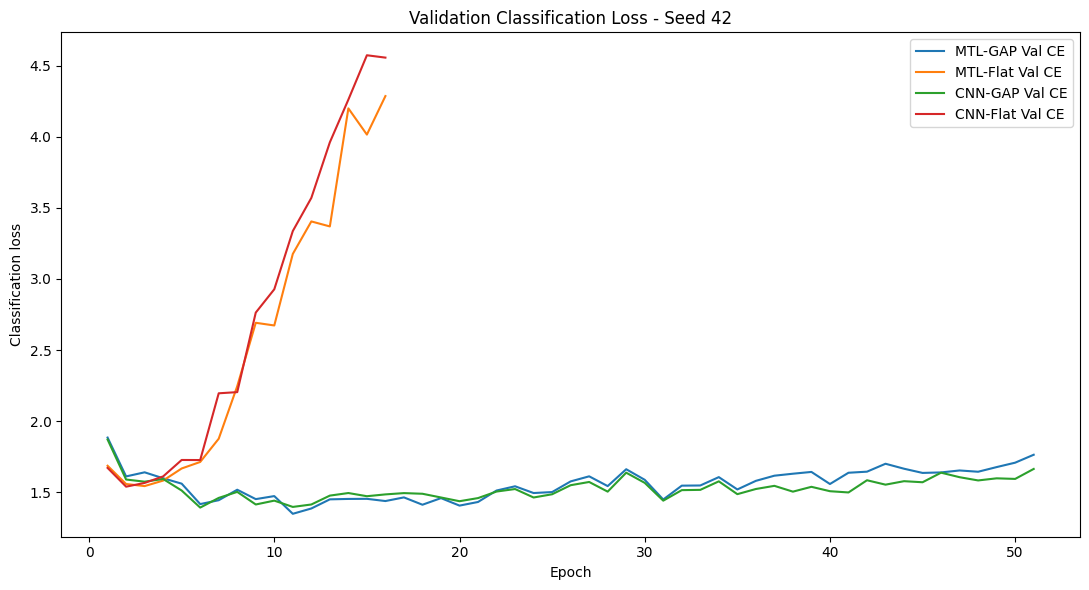

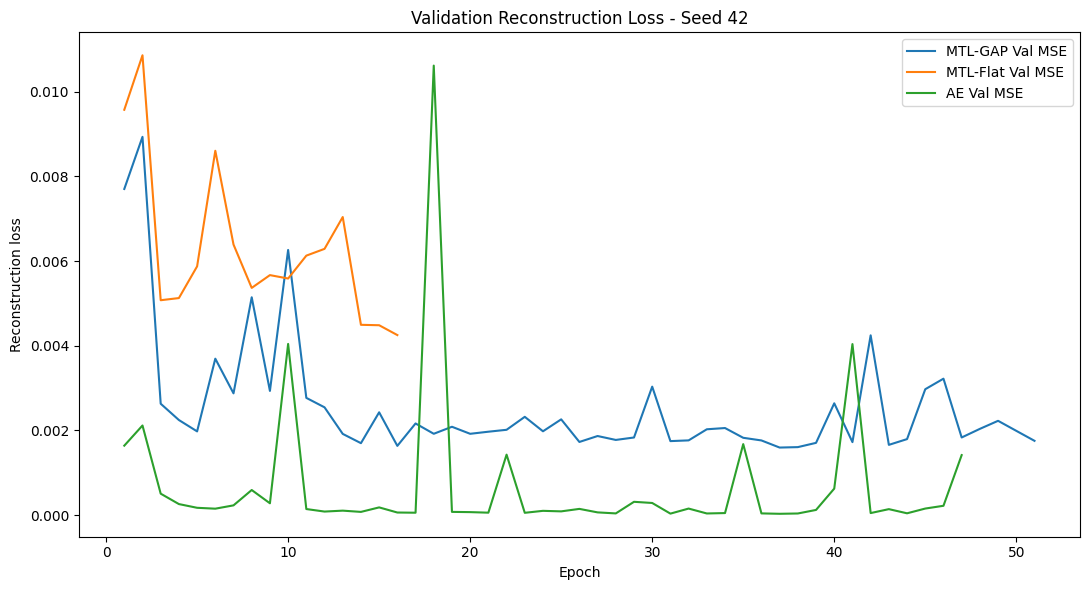

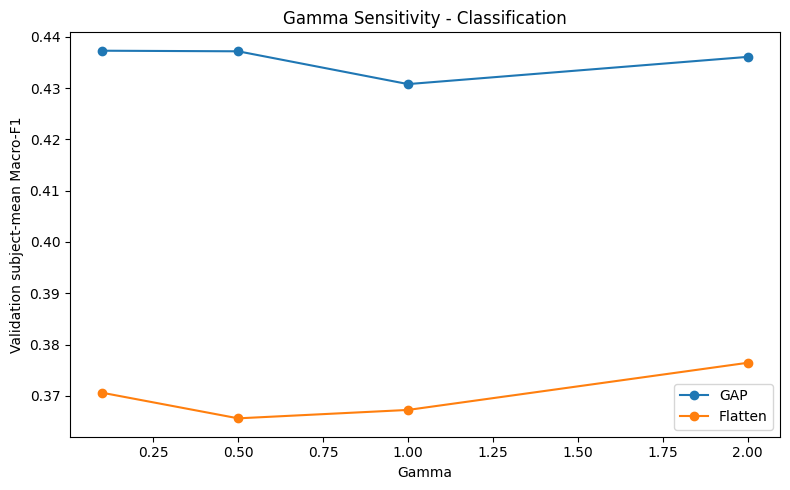

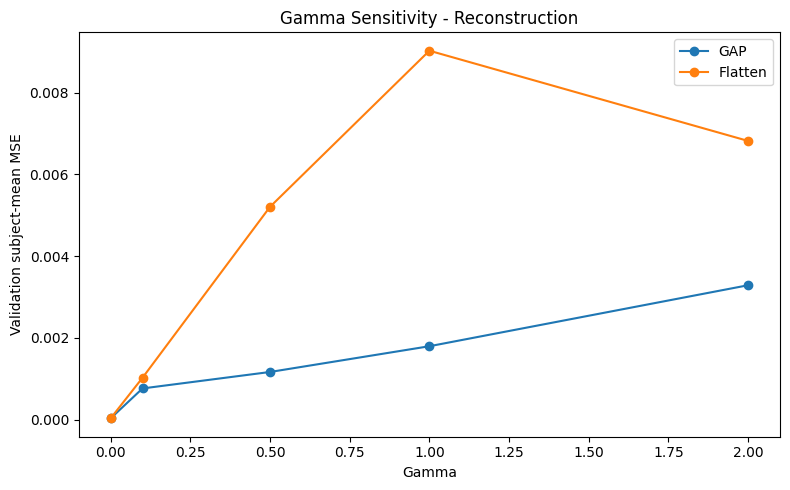

In [43]:
# PHASE 7.5 - TRAINING CURVES AND GAMMA FIGURES

classification_models = [
    "MTL-GAP",
    "MTL-Flat",
    "CNN-GAP",
    "CNN-Flat"
]


plt.figure(
    figsize=(11, 6)
)

for model_name in classification_models:

    safe_name = (
        model_name
        .lower()
        .replace(
            "-",
            "_"
        )
    )

    history = pd.read_csv(
        RESULTS_DIR
        / (
            f"history_"
            f"{safe_name}_"
            f"seed42_main.csv"
        )
    )

    plt.plot(
        history["epoch"],
        history[
            "val_classification_loss"
        ],
        label=(
            f"{model_name} Val CE"
        )
    )


plt.xlabel("Epoch")
plt.ylabel("Classification loss")
plt.title(
    "Validation Classification Loss - Seed 42"
)
plt.legend()
plt.tight_layout()

plt.savefig(
    FIGURE_DIR
    / "validation-classification-loss-seed42.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


plt.figure(
    figsize=(11, 6)
)

for model_name in [
    "MTL-GAP",
    "MTL-Flat",
    "AE"
]:

    safe_name = (
        model_name
        .lower()
        .replace(
            "-",
            "_"
        )
    )

    history = pd.read_csv(
        RESULTS_DIR
        / (
            f"history_"
            f"{safe_name}_"
            f"seed42_main.csv"
        )
    )

    plt.plot(
        history["epoch"],
        history[
            "val_reconstruction_loss"
        ],
        label=(
            f"{model_name} Val MSE"
        )
    )


plt.xlabel("Epoch")
plt.ylabel("Reconstruction loss")
plt.title(
    "Validation Reconstruction Loss - Seed 42"
)
plt.legend()
plt.tight_layout()

plt.savefig(
    FIGURE_DIR
    / "validation-reconstruction-loss-seed42.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


gamma_plot = gamma_sensitivity[
    gamma_sensitivity[
        "head"
    ].isin(
        [
            "GAP",
            "Flatten"
        ]
    )
]


plt.figure(
    figsize=(8, 5)
)

for head in [
    "GAP",
    "Flatten"
]:
    subset = (
        gamma_plot[
            gamma_plot[
                "head"
            ] == head
        ]
        .sort_values(
            "gamma"
        )
    )

    plt.plot(
        subset["gamma"],
        subset[
            "val_subject_macro_f1"
        ],
        marker="o",
        label=head
    )


plt.xlabel("Gamma")
plt.ylabel(
    "Validation subject-mean Macro-F1"
)
plt.title(
    "Gamma Sensitivity - Classification"
)
plt.legend()
plt.tight_layout()

plt.savefig(
    FIGURE_DIR
    / "gamma-sensitivity-macro-f1.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


plt.figure(
    figsize=(8, 5)
)

for head in [
    "GAP",
    "Flatten"
]:
    subset = (
        gamma_plot[
            gamma_plot[
                "head"
            ] == head
        ]
        .sort_values(
            "gamma"
        )
    )

    plt.plot(
        subset["gamma"],
        subset[
            "val_subject_reconstruction_mse"
        ],
        marker="o",
        label=head
    )


plt.xlabel("Gamma")
plt.ylabel(
    "Validation subject-mean MSE"
)
plt.title(
    "Gamma Sensitivity - Reconstruction"
)
plt.legend()
plt.tight_layout()

plt.savefig(
    FIGURE_DIR
    / "gamma-sensitivity-reconstruction-mse.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# Phase 7 – Kết luận

Toàn bộ ngân sách huấn luyện theo đề cương đã hoàn tất:

- **15/15 main experiments**;
- **6/6 additional γ runs**;
- tổng cộng **21 lượt huấn luyện**.

Checkpoint classification được chọn theo Validation subject-mean Macro-F1, còn AE được chọn theo Validation subject-mean MSE.

Ở 15 main runs, best Validation Macro-F1 theo seed:

- MTL-GAP: **0.4308, 0.4343, 0.4106**;
- MTL-Flat: **0.3673, 0.3644, 0.3646**;
- CNN-GAP: **0.4444, 0.4155, 0.4244**;
- CNN-Flat: **0.3932, 0.3677, 0.3596**.

AE đạt best Validation subject-level MSE lần lượt khoảng **3.5e-5, 1.9e-5 và 4.7e-5**.

## Khảo sát γ trên Validation, seed 42

Với GAP:

- γ=0.1: Macro-F1 **0.4373**, reconstruction MSE **0.000766**;
- γ=0.5: Macro-F1 **0.4372**, reconstruction MSE **0.001169**;
- γ=1.0: Macro-F1 **0.4308**, reconstruction MSE **0.001799**;
- γ=2.0: Macro-F1 **0.4361**, reconstruction MSE **0.003290**.

Với Flatten:

- γ=0.1: Macro-F1 **0.3706**, reconstruction MSE **0.001028**;
- γ=0.5: Macro-F1 **0.3656**, reconstruction MSE **0.005208**;
- γ=1.0: Macro-F1 **0.3673**, reconstruction MSE **0.009026**;
- γ=2.0: Macro-F1 **0.3764**, reconstruction MSE **0.006819**.

Khảo sát này chỉ mang tính thăm dò trên Validation với một seed. Nó cho thấy thay đổi γ tạo trade-off giữa classification và reconstruction; không dùng kết quả này để thay đổi cấu hình Test chính đã khóa ở γ=1.

# Phase 8 – Final Test Evaluation

Chỉ load **checkpoint main** đã khóa bằng Validation.

Đánh giá Test theo đúng đơn vị tổng hợp:

1. tính metric riêng cho từng subject;
2. trong mỗi seed, lấy trung bình không trọng số giữa S13, S14, S15;
3. báo mean ± SD giữa ba seed.

## Classification

- Accuracy;
- Macro-F1 với `labels=[0,...,7]`, `zero_division=0`;
- F1 từng lớp;
- support từng lớp;
- confusion matrix.

## Reconstruction

- MSE từng window;
- PRD_c từng window;
- tổng hợp theo subject;
- đếm số window có PRD_c không xác định.

Không trộn metric pooled-window với metric subject-balanced trong bảng kết quả chính.


In [44]:
# PHASE 8.1 - COMPREHENSIVE TEST EVALUATION

def load_main_checkpoint(
    model_name,
    seed,
    target_device=device
):
    checkpoint_path = (
        CHECKPOINT_DIR
        / checkpoint_filename(
            model_name,
            seed,
            "main"
        )
    )

    if not checkpoint_path.exists():
        raise FileNotFoundError(
            checkpoint_path
        )

    model = (
        build_model(
            model_name
        )
        .to(
            target_device
        )
    )

    checkpoint = torch.load(
        checkpoint_path,
        map_location=target_device
    )

    model.load_state_dict(
        checkpoint[
            "model_state_dict"
        ]
    )

    model.eval()

    return (
        model,
        checkpoint
    )


def prd_c_per_window(
    reference,
    reconstruction
):
    error_sq = torch.sum(
        (
            reconstruction
            - reference
        ) ** 2,
        dim=(1, 2)
    )

    reference_centered = (
        reference
        - reference.mean(
            dim=2,
            keepdim=True
        )
    )

    denom_sq = torch.sum(
        reference_centered ** 2,
        dim=(1, 2)
    )

    threshold = (
        1e-12
        * CONFIG[
            "window_size"
        ]
    )

    valid = (
        denom_sq > threshold
    )

    prd = torch.full_like(
        denom_sq,
        float("nan")
    )

    prd[valid] = (
        100.0
        * torch.sqrt(
            error_sq[valid]
            / denom_sq[valid]
        )
    )

    return prd


window_rows = []
subject_rows = []
per_class_rows = []


for model_name in MODEL_NAMES:

    for seed in CONFIG["seeds"]:

        print(
            f"TEST | {model_name} | seed={seed}"
        )

        model, checkpoint = (
            load_main_checkpoint(
                model_name,
                seed
            )
        )

        per_subject_buffers = {
            subject_id: {
                "y_true": [],
                "y_pred": [],
                "mse": [],
                "prd_c": [],
                "prd_undefined": 0
            }
            for subject_id in CONFIG[
                "test_subjects"
            ]
        }

        with torch.inference_mode():

            for (
                x,
                y,
                subject_idx,
                start_sample
            ) in test_loader:

                x_device = x.to(
                    device,
                    non_blocking=True
                )

                y_device = y.to(
                    device,
                    non_blocking=True
                )

                output = model(
                    x_device
                )

                logits = None
                reconstruction = None

                if model_name.startswith(
                    "MTL"
                ):
                    (
                        logits,
                        reconstruction
                    ) = output

                elif model_name.startswith(
                    "CNN"
                ):
                    logits = output

                else:
                    reconstruction = output

                if logits is not None:
                    pred = torch.argmax(
                        logits,
                        dim=1
                    ).detach().cpu().numpy()
                else:
                    pred = np.full(
                        len(y),
                        -1,
                        dtype=np.int64
                    )

                if reconstruction is not None:
                    mse_window = torch.mean(
                        (
                            reconstruction
                            - x_device
                        ) ** 2,
                        dim=(1, 2)
                    ).detach().cpu().numpy()

                    prd_window = (
                        prd_c_per_window(
                            x_device,
                            reconstruction
                        )
                        .detach()
                        .cpu()
                        .numpy()
                    )
                else:
                    mse_window = np.full(
                        len(y),
                        np.nan
                    )

                    prd_window = np.full(
                        len(y),
                        np.nan
                    )

                y_np = y.numpy()
                sid_np = subject_idx.numpy()
                start_np = start_sample.numpy()

                for i in range(
                    len(y_np)
                ):
                    subject_id = CONFIG[
                        "subjects"
                    ][
                        int(
                            sid_np[i]
                        )
                    ]

                    pred_value = (
                        int(pred[i])
                        if logits
                        is not None
                        else np.nan
                    )

                    mse_value = (
                        float(
                            mse_window[i]
                        )
                        if reconstruction
                        is not None
                        else np.nan
                    )

                    prd_value = (
                        float(
                            prd_window[i]
                        )
                        if reconstruction
                        is not None
                        else np.nan
                    )

                    window_rows.append({
                        "model": model_name,
                        "seed": seed,
                        "subject": subject_id,
                        "start_sample": int(
                            start_np[i]
                        ),
                        "start_time_s": (
                            int(
                                start_np[i]
                            )
                            / CONFIG[
                                "fs"
                            ]
                        ),
                        "true_label": int(
                            y_np[i]
                        ),
                        "pred_label": pred_value,
                        "mse": mse_value,
                        "prd_c": prd_value
                    })

                    buffer = (
                        per_subject_buffers[
                            subject_id
                        ]
                    )

                    if logits is not None:
                        buffer[
                            "y_true"
                        ].append(
                            int(
                                y_np[i]
                            )
                        )

                        buffer[
                            "y_pred"
                        ].append(
                            int(
                                pred[i]
                            )
                        )

                    if reconstruction is not None:
                        buffer["mse"].append(
                            mse_value
                        )

                        if np.isfinite(
                            prd_value
                        ):
                            buffer[
                                "prd_c"
                            ].append(
                                prd_value
                            )
                        else:
                            buffer[
                                "prd_undefined"
                            ] += 1

        for subject_id in CONFIG[
            "test_subjects"
        ]:
            buffer = (
                per_subject_buffers[
                    subject_id
                ]
            )

            accuracy = np.nan
            macro_f1 = np.nan

            if len(
                buffer[
                    "y_true"
                ]
            ) > 0:
                y_true_s = np.asarray(
                    buffer[
                        "y_true"
                    ]
                )

                y_pred_s = np.asarray(
                    buffer[
                        "y_pred"
                    ]
                )

                accuracy = accuracy_score(
                    y_true_s,
                    y_pred_s
                )

                macro_f1 = f1_score(
                    y_true_s,
                    y_pred_s,
                    labels=list(
                        range(
                            CONFIG[
                                "num_classes"
                            ]
                        )
                    ),
                    average="macro",
                    zero_division=0
                )

                f1_each = f1_score(
                    y_true_s,
                    y_pred_s,
                    labels=list(
                        range(
                            CONFIG[
                                "num_classes"
                            ]
                        )
                    ),
                    average=None,
                    zero_division=0
                )

                support_each = np.asarray([
                    np.sum(
                        y_true_s == class_id
                    )
                    for class_id in range(
                        CONFIG[
                            "num_classes"
                        ]
                    )
                ])

                for class_id in range(
                    CONFIG[
                        "num_classes"
                    ]
                ):
                    per_class_rows.append({
                        "model": model_name,
                        "seed": seed,
                        "subject": subject_id,
                        "class_id": class_id,
                        "activity": task_activities[
                            class_id
                        ],
                        "f1": float(
                            f1_each[
                                class_id
                            ]
                        ),
                        "support": int(
                            support_each[
                                class_id
                            ]
                        )
                    })

            mse_subject = (
                float(
                    np.mean(
                        buffer["mse"]
                    )
                )
                if len(
                    buffer["mse"]
                ) > 0
                else np.nan
            )

            prd_subject = (
                float(
                    np.mean(
                        buffer[
                            "prd_c"
                        ]
                    )
                )
                if len(
                    buffer[
                        "prd_c"
                    ]
                ) > 0
                else np.nan
            )

            subject_rows.append({
                "model": model_name,
                "seed": seed,
                "subject": subject_id,
                "accuracy": accuracy,
                "macro_f1": macro_f1,
                "mse": mse_subject,
                "prd_c": prd_subject,
                "prd_c_undefined_windows": (
                    buffer[
                        "prd_undefined"
                    ]
                )
            })

        del model
        gc.collect()

        if torch.cuda.is_available():
            torch.cuda.empty_cache()


test_per_window = pd.DataFrame(
    window_rows
)

test_per_subject = pd.DataFrame(
    subject_rows
)

test_per_class = pd.DataFrame(
    per_class_rows
)


# Subject-balanced metric per seed
seed_rows = []

for model_name in MODEL_NAMES:

    for seed in CONFIG["seeds"]:

        subset = test_per_subject[
            (
                test_per_subject[
                    "model"
                ] == model_name
            )
            & (
                test_per_subject[
                    "seed"
                ] == seed
            )
        ]

        seed_rows.append({
            "model": model_name,
            "seed": seed,
            "accuracy": (
                subset[
                    "accuracy"
                ].mean()
            ),
            "macro_f1": (
                subset[
                    "macro_f1"
                ].mean()
            ),
            "mse": (
                subset[
                    "mse"
                ].mean()
            ),
            "prd_c": (
                subset[
                    "prd_c"
                ].mean()
            ),
            "prd_c_undefined_windows": int(
                subset[
                    "prd_c_undefined_windows"
                ].sum()
            )
        })


test_per_seed = pd.DataFrame(
    seed_rows
)


# Mean ± SD across the three seed-level values
summary_rows = []

for model_name in MODEL_NAMES:

    subset = test_per_seed[
        test_per_seed[
            "model"
        ] == model_name
    ]

    row = {
        "model": model_name
    }

    for metric in [
        "accuracy",
        "macro_f1",
        "mse",
        "prd_c"
    ]:
        values = (
            subset[metric]
            .dropna()
            .to_numpy(
                dtype=float
            )
        )

        row[
            f"{metric}_mean"
        ] = (
            float(
                np.mean(
                    values
                )
            )
            if len(values) > 0
            else np.nan
        )

        row[
            f"{metric}_std"
        ] = (
            float(
                np.std(
                    values,
                    ddof=1
                )
            )
            if len(values) > 1
            else np.nan
        )

    summary_rows.append(
        row
    )


test_summary = pd.DataFrame(
    summary_rows
)


test_per_window.to_csv(
    RESULTS_DIR
    / "test-per-window.csv",
    index=False
)

test_per_subject.to_csv(
    RESULTS_DIR
    / "test-per-subject.csv",
    index=False
)

test_per_seed.to_csv(
    RESULTS_DIR
    / "test-per-seed.csv",
    index=False
)

test_per_class.to_csv(
    RESULTS_DIR
    / "test-per-class-f1-support.csv",
    index=False
)

test_summary.to_csv(
    RESULTS_DIR
    / "test-summary-subject-balanced.csv",
    index=False
)


display(
    test_per_subject
)

display(
    test_per_seed
)

display(
    test_summary
)

print(
    "Subject-balanced Test evaluation: PASSED"
)


TEST | MTL-GAP | seed=42
TEST | MTL-GAP | seed=43
TEST | MTL-GAP | seed=44
TEST | MTL-Flat | seed=42
TEST | MTL-Flat | seed=43
TEST | MTL-Flat | seed=44
TEST | CNN-GAP | seed=42
TEST | CNN-GAP | seed=43
TEST | CNN-GAP | seed=44
TEST | CNN-Flat | seed=42
TEST | CNN-Flat | seed=43
TEST | CNN-Flat | seed=44
TEST | AE | seed=42
TEST | AE | seed=43
TEST | AE | seed=44


,model,seed,subject,accuracy,macro_f1,mse,prd_c,prd_c_undefined_windows
0,MTL-GAP,42,S13,0.499701,0.410356,0.001858,3.637362,0
1,MTL-GAP,42,S14,0.553030,0.450380,0.002608,3.493115,0
2,MTL-GAP,42,S15,0.449725,0.405452,0.000579,4.419599,0
3,MTL-GAP,43,S13,0.439258,0.338553,0.001772,3.560027,0
4,MTL-GAP,43,S14,0.491793,0.372836,0.002330,3.351939,0
5,MTL-GAP,43,S15,0.466942,0.420627,0.000527,4.200655,0
6,MTL-GAP,44,S13,0.456014,0.347372,0.003076,4.960015,0
7,MTL-GAP,44,S14,0.423611,0.323365,0.003871,4.569110,0
8,MTL-GAP,44,S15,0.400138,0.322130,0.001093,6.356544,0
9,MTL-Flat,42,S13,0.408139,0.353877,0.008984,8.221888,0


,model,seed,accuracy,macro_f1,mse,prd_c,prd_c_undefined_windows
0,MTL-GAP,42,0.500819,0.422063,0.001682,3.850026,0
1,MTL-GAP,43,0.465998,0.377339,0.001543,3.704207,0
2,MTL-GAP,44,0.426588,0.330956,0.002680,5.295223,0
3,MTL-Flat,42,0.413958,0.357410,0.008421,8.768690,0
4,MTL-Flat,43,0.413761,0.355816,0.006169,7.411852,0
5,MTL-Flat,44,0.417035,0.353221,0.005216,6.586483,0
6,CNN-GAP,42,0.480409,0.410311,NaN,NaN,0
7,CNN-GAP,43,0.503524,0.429188,NaN,NaN,0
8,CNN-GAP,44,0.490094,0.391668,NaN,NaN,0
9,CNN-Flat,42,0.395631,0.352499,NaN,NaN,0


,model,accuracy_mean,accuracy_std,macro_f1_mean,macro_f1_std,mse_mean,mse_std,prd_c_mean,prd_c_std
0,MTL-GAP,0.464468,0.037139,0.376786,0.045556,0.001968,0.000620,4.283152,0.879506
1,MTL-Flat,0.414918,0.001836,0.355482,0.002114,0.006602,0.001646,7.589008,1.101837
2,CNN-GAP,0.491343,0.011608,0.410389,0.018760,NaN,NaN,NaN,NaN
3,CNN-Flat,0.398171,0.004945,0.334891,0.015402,NaN,NaN,NaN,NaN
4,AE,NaN,NaN,NaN,NaN,0.000032,0.000013,0.535848,0.121102


Subject-balanced Test evaluation: PASSED


,model,class_id,activity,f1_mean,f1_std,support_total
0,CNN-Flat,0,BASELINE,0.458248,0.114117,450
1,CNN-Flat,1,STAIRS,0.200976,0.064272,336
2,CNN-Flat,2,SOCCER,0.048144,0.014761,237
3,CNN-Flat,3,CYCLING,0.484801,0.019194,345
4,CNN-Flat,4,DRIVING,0.279645,0.016398,653
5,CNN-Flat,5,LUNCH,0.434564,0.017814,1294
6,CNN-Flat,6,WALKING,0.356279,0.058740,490
7,CNN-Flat,7,WORKING,0.416470,0.026585,902
8,CNN-GAP,0,BASELINE,0.511200,0.183022,450
9,CNN-GAP,1,STAIRS,0.255721,0.042200,336


Per-class aggregation check: PASSED


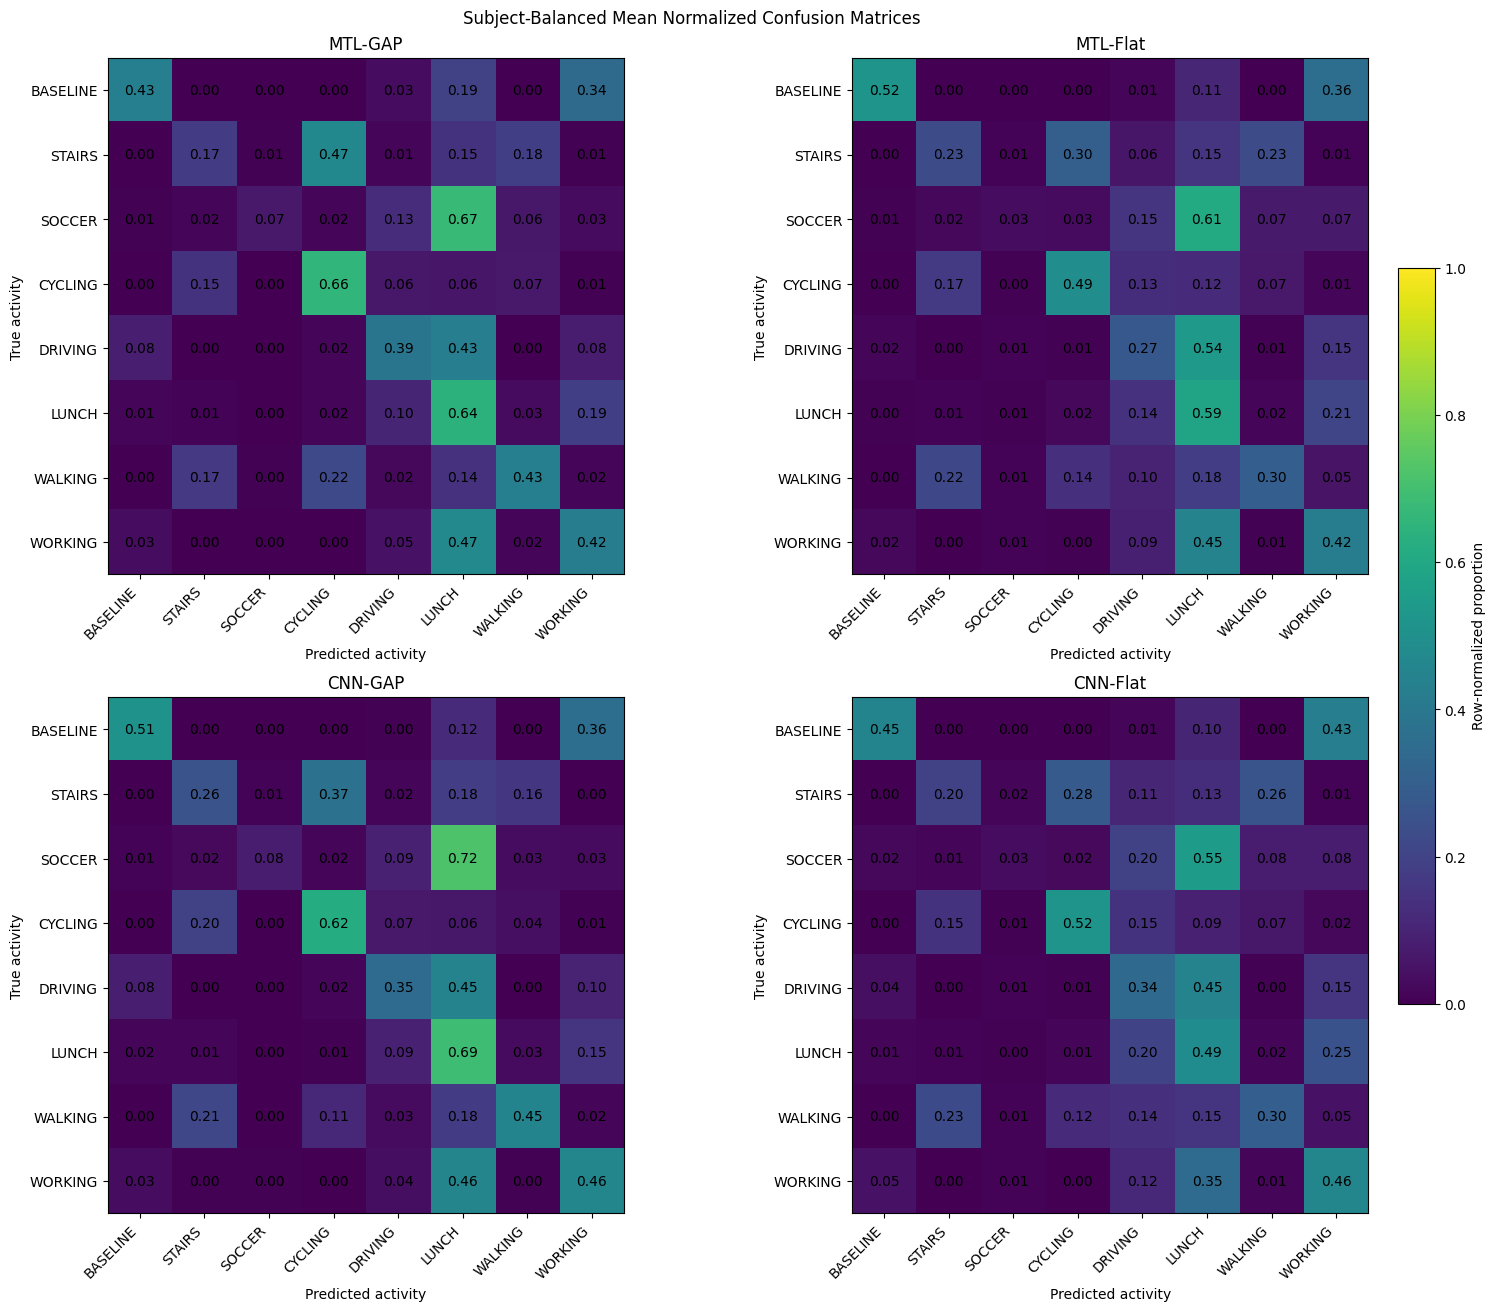

In [45]:
# PHASE 8.2 - PER-CLASS F1 AND CONFUSION MATRICES

classification_models = [
    "MTL-GAP",
    "MTL-Flat",
    "CNN-GAP",
    "CNN-Flat"
]


# Aggregate per-class F1 using the same protocol as the main metrics:
# subject -> seed -> mean ± SD across seeds.
#
# Support is reported once for the actual Test set, not summed again
# across the three repeated seed evaluations.

per_class_per_seed = (
    test_per_class
    .groupby(
        [
            "model",
            "seed",
            "class_id",
            "activity"
        ],
        as_index=False
    )
    .agg(
        f1_subject_mean=(
            "f1",
            "mean"
        ),
        support_seed=(
            "support",
            "sum"
        )
    )
)

support_consistency = (
    per_class_per_seed
    .groupby(
        [
            "model",
            "class_id"
        ]
    )[
        "support_seed"
    ]
    .nunique()
)

assert (
    support_consistency == 1
).all(), (
    "Per-class Test support changed across seeds."
)

per_class_summary = (
    per_class_per_seed
    .groupby(
        [
            "model",
            "class_id",
            "activity"
        ],
        as_index=False
    )
    .agg(
        f1_mean=(
            "f1_subject_mean",
            "mean"
        ),
        f1_std=(
            "f1_subject_mean",
            "std"
        ),
        support_total=(
            "support_seed",
            "first"
        )
    )
)

per_class_per_seed.to_csv(
    RESULTS_DIR
    / "test-per-class-seed-summary.csv",
    index=False
)

per_class_summary.to_csv(
    RESULTS_DIR
    / "test-per-class-summary.csv",
    index=False
)

display(
    per_class_summary
)

print(
    "Per-class aggregation check: PASSED"
)


mean_confusion = {}


for model_name in classification_models:

    row_accumulators = {
        class_id: []
        for class_id in range(
            CONFIG[
                "num_classes"
            ]
        )
    }

    for seed in CONFIG["seeds"]:

        for subject_id in CONFIG[
            "test_subjects"
        ]:
            subset = test_per_window[
                (
                    test_per_window[
                        "model"
                    ] == model_name
                )
                & (
                    test_per_window[
                        "seed"
                    ] == seed
                )
                & (
                    test_per_window[
                        "subject"
                    ] == subject_id
                )
            ]

            y_true = (
                subset[
                    "true_label"
                ]
                .to_numpy(
                    dtype=int
                )
            )

            y_pred = (
                subset[
                    "pred_label"
                ]
                .to_numpy(
                    dtype=int
                )
            )

            cm_counts = confusion_matrix(
                y_true,
                y_pred,
                labels=list(
                    range(
                        CONFIG[
                            "num_classes"
                        ]
                    )
                )
            )

            for class_id in range(
                CONFIG[
                    "num_classes"
                ]
            ):
                support = (
                    cm_counts[
                        class_id
                    ].sum()
                )

                if support > 0:
                    row_accumulators[
                        class_id
                    ].append(
                        cm_counts[
                            class_id
                        ]
                        / support
                    )

    cm_mean = np.zeros(
        (
            CONFIG[
                "num_classes"
            ],
            CONFIG[
                "num_classes"
            ]
        ),
        dtype=float
    )

    for class_id in range(
        CONFIG[
            "num_classes"
        ]
    ):
        rows = (
            row_accumulators[
                class_id
            ]
        )

        if len(rows) > 0:
            cm_mean[
                class_id
            ] = np.mean(
                rows,
                axis=0
            )

    mean_confusion[
        model_name
    ] = cm_mean


fig, axes = plt.subplots(
    2,
    2,
    figsize=(16, 13),
    constrained_layout=True
)

axes = axes.ravel()

for ax, model_name in zip(
    axes,
    classification_models
):
    cm = mean_confusion[
        model_name
    ]

    image = ax.imshow(
        cm,
        vmin=0,
        vmax=1
    )

    ax.set_title(
        model_name
    )

    ax.set_xlabel(
        "Predicted activity"
    )

    ax.set_ylabel(
        "True activity"
    )

    ax.set_xticks(
        range(
            CONFIG[
                "num_classes"
            ]
        )
    )

    ax.set_yticks(
        range(
            CONFIG[
                "num_classes"
            ]
        )
    )

    ax.set_xticklabels(
        task_activities,
        rotation=45,
        ha="right"
    )

    ax.set_yticklabels(
        task_activities
    )

    for i in range(
        CONFIG[
            "num_classes"
        ]
    ):
        for j in range(
            CONFIG[
                "num_classes"
            ]
        ):
            ax.text(
                j,
                i,
                f"{cm[i, j]:.2f}",
                ha="center",
                va="center"
            )


fig.colorbar(
    image,
    ax=axes.tolist(),
    fraction=0.025,
    pad=0.02,
    label="Row-normalized proportion"
)

fig.suptitle(
    "Subject-Balanced Mean Normalized Confusion Matrices"
)

plt.savefig(
    FIGURE_DIR
    / "confusion-matrices-subject-balanced.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


,subject,class_id,dataset_index,start_sample
0,S13,0,0,4608
1,S13,1,149,52480
2,S13,2,271,90880
3,S13,3,342,138496
4,S13,4,464,213248
5,S13,5,687,297216
6,S13,6,1192,427008
7,S13,7,1367,493568
8,S14,0,1671,4096
9,S14,1,1821,52224


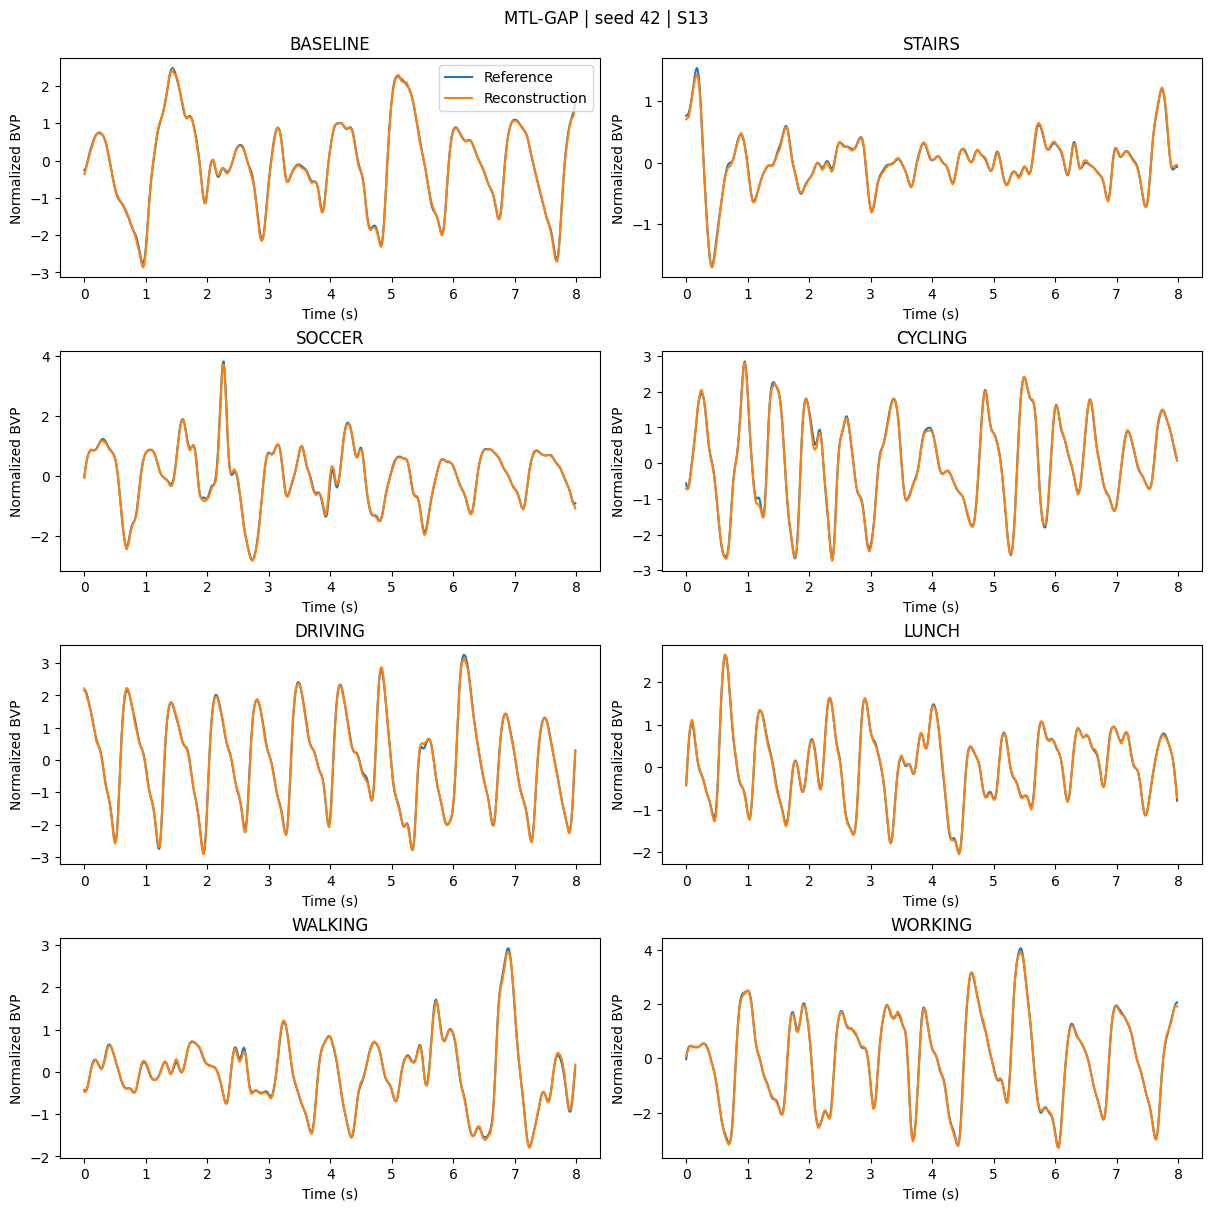

Reconstruction example figures saved.


In [46]:
# PHASE 8.3 - PREDEFINED RECONSTRUCTION EXAMPLES

reconstruction_models = [
    "MTL-GAP",
    "MTL-Flat",
    "AE"
]

# Deterministic rule:
# first valid window of every available class
# for every Test subject, seed 42.

test_meta = pd.DataFrame({
    "dataset_index": np.arange(
        len(
            split_data[
                "test"
            ]["y"]
        )
    ),
    "subject": split_data[
        "test"
    ]["subject"],
    "class_id": split_data[
        "test"
    ]["y"],
    "start_sample": split_data[
        "test"
    ]["start_sample"]
})


selected_examples = (
    test_meta
    .sort_values(
        [
            "subject",
            "class_id",
            "start_sample"
        ]
    )
    .groupby(
        [
            "subject",
            "class_id"
        ],
        as_index=False
    )
    .first()
)


display(
    selected_examples
)


for model_name in reconstruction_models:

    model, checkpoint = (
        load_main_checkpoint(
            model_name,
            42
        )
    )

    for subject_id in CONFIG[
        "test_subjects"
    ]:

        subject_examples = (
            selected_examples[
                selected_examples[
                    "subject"
                ] == subject_id
            ]
            .sort_values(
                "class_id"
            )
        )

        fig, axes = plt.subplots(
            4,
            2,
            figsize=(12, 12),
            constrained_layout=True
        )

        axes = axes.ravel()

        for ax_index, ax in enumerate(
            axes
        ):
            if (
                ax_index
                >= len(
                    subject_examples
                )
            ):
                ax.axis("off")
                continue

            row = (
                subject_examples
                .iloc[
                    ax_index
                ]
            )

            dataset_index = int(
                row[
                    "dataset_index"
                ]
            )

            x, y, _, _ = (
                test_dataset[
                    dataset_index
                ]
            )

            x_input = (
                x.unsqueeze(0)
                .to(device)
            )

            with torch.inference_mode():
                output = model(
                    x_input
                )

            if model_name.startswith(
                "MTL"
            ):
                reconstruction = (
                    output[1]
                    .squeeze(0)
                    .squeeze(0)
                    .detach()
                    .cpu()
                    .numpy()
                )
            else:
                reconstruction = (
                    output
                    .squeeze(0)
                    .squeeze(0)
                    .detach()
                    .cpu()
                    .numpy()
                )

            reference = (
                x.squeeze(0)
                .numpy()
            )

            t = np.arange(
                WINDOW_SIZE
            ) / CONFIG["fs"]

            ax.plot(
                t,
                reference,
                label="Reference"
            )

            ax.plot(
                t,
                reconstruction,
                label="Reconstruction"
            )

            class_id = int(
                row[
                    "class_id"
                ]
            )

            ax.set_title(
                task_activities[
                    class_id
                ]
            )

            ax.set_xlabel(
                "Time (s)"
            )

            ax.set_ylabel(
                "Normalized BVP"
            )

            if ax_index == 0:
                ax.legend()

        fig.suptitle(
            f"{model_name} | "
            f"seed 42 | "
            f"{subject_id}"
        )

        output_path = (
            FIGURE_DIR
            / (
                f"reconstruction-"
                f"{model_name.lower().replace('-', '_')}-"
                f"seed42-"
                f"{subject_id}.png"
            )
        )

        plt.savefig(
            output_path,
            dpi=300,
            bbox_inches="tight"
        )

        if (
            model_name
            == "MTL-GAP"
            and subject_id
            == CONFIG[
                "test_subjects"
            ][0]
        ):
            plt.show()
        else:
            plt.close(fig)

    del model
    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()


print(
    "Reconstruction example figures saved."
)


# Phase 8 – Kết luận

Đánh giá Test được thực hiện bằng các checkpoint main đã khóa từ Validation và tổng hợp đúng theo subject:

1. tính metric riêng cho S13, S14, S15;
2. lấy trung bình không trọng số giữa ba subject trong từng seed;
3. báo mean ± SD giữa ba seed.

## Kết quả classification

- **MTL-GAP:** Accuracy **0.4645 ± 0.0371**, Macro-F1 **0.3768 ± 0.0456**;
- **MTL-Flat:** Accuracy **0.4149 ± 0.0018**, Macro-F1 **0.3555 ± 0.0021**;
- **CNN-GAP:** Accuracy **0.4913 ± 0.0116**, Macro-F1 **0.4104 ± 0.0188**;
- **CNN-Flat:** Accuracy **0.3982 ± 0.0049**, Macro-F1 **0.3349 ± 0.0154**.

Trong bốn mô hình classification, **CNN-GAP đạt Accuracy và Macro-F1 trung bình cao nhất** trên split Test này.

## Kết quả reconstruction

- **MTL-GAP:** MSE **0.001968 ± 0.000620**, PRD_c **4.283 ± 0.880%**;
- **MTL-Flat:** MSE **0.006602 ± 0.001646**, PRD_c **7.589 ± 1.102%**;
- **AE:** MSE **0.000032 ± 0.000013**, PRD_c **0.536 ± 0.121%**.

Không có window nào có `PRD_c` không xác định trong các kết quả Test.

## F1 từng lớp

F1 từng lớp được tổng hợp theo cùng protocol với metric chính: trước hết lấy trung bình không trọng số giữa các Test subject trong từng seed, sau đó báo **mean ± SD giữa ba seed**. `support_total` chỉ đếm số window thật của Test set một lần, không cộng lặp qua ba seed.

`SOCCER` là lớp khó nhất một cách nhất quán ở cả bốn mô hình classification. Với CNN-GAP, F1 trung bình của SOCCER khoảng **0.126**, trong khi các lớp như LUNCH, WALKING và CYCLING đạt F1 cao hơn.

Các file per-window, per-subject, per-seed, per-class, confusion matrix và các ví dụ reconstruction theo quy tắc định trước đã được lưu đầy đủ.


# Phase 9 – GAP vs Flatten, Multi-task Ablation và Resource Evaluation

Phân tích cuối phải tách ba câu hỏi:

1. GAP vs Flatten ảnh hưởng classification thế nào?
2. Trong MTL, reconstruction thay đổi thế nào?
3. Multi-task có giúp classification so với CNN đơn nhiệm cùng head hay không?

Ngoài chất lượng, đánh giá tài nguyên theo đúng protocol CPU:

- 1 thread;
- batch size 1;
- float32;
- input đã nằm trong RAM;
- `model.eval()` + `inference_mode()`;
- warm-up 100;
- 1,000 forward passes;
- lặp 3 phiên;
- báo mean, median, P95.

Đối với MTL, báo riêng:

- full graph: encoder + decoder + classifier;
- classification-only graph: encoder + classifier.


In [47]:
# PHASE 9.1 - QUALITY COMPARISONS AND PAIRED DELTAS

def summary_metric(
    model_name,
    metric
):
    return float(
        test_summary.loc[
            test_summary[
                "model"
            ] == model_name,
            metric
        ].iloc[0]
    )


gap_flat_rows = []


for family, gap_model, flat_model in [
    (
        "MTL",
        "MTL-GAP",
        "MTL-Flat"
    ),
    (
        "CNN",
        "CNN-GAP",
        "CNN-Flat"
    )
]:

    row = {
        "family": family,
        "gap_accuracy": summary_metric(
            gap_model,
            "accuracy_mean"
        ),
        "flat_accuracy": summary_metric(
            flat_model,
            "accuracy_mean"
        ),
        "gap_macro_f1": summary_metric(
            gap_model,
            "macro_f1_mean"
        ),
        "flat_macro_f1": summary_metric(
            flat_model,
            "macro_f1_mean"
        )
    }

    row[
        "accuracy_delta_gap_minus_flat"
    ] = (
        row["gap_accuracy"]
        - row[
            "flat_accuracy"
        ]
    )

    row[
        "macro_f1_delta_gap_minus_flat"
    ] = (
        row["gap_macro_f1"]
        - row[
            "flat_macro_f1"
        ]
    )

    if family == "MTL":
        row["gap_mse"] = summary_metric(
            gap_model,
            "mse_mean"
        )

        row["flat_mse"] = summary_metric(
            flat_model,
            "mse_mean"
        )

        row["gap_prd_c"] = summary_metric(
            gap_model,
            "prd_c_mean"
        )

        row["flat_prd_c"] = summary_metric(
            flat_model,
            "prd_c_mean"
        )

    gap_flat_rows.append(
        row
    )


gap_flat_comparison = pd.DataFrame(
    gap_flat_rows
)


# Paired subject-level deltas
paired_rows = []

for (
    family,
    gap_model,
    flat_model
) in [
    (
        "MTL",
        "MTL-GAP",
        "MTL-Flat"
    ),
    (
        "CNN",
        "CNN-GAP",
        "CNN-Flat"
    )
]:

    gap_df = (
        test_per_subject[
            test_per_subject[
                "model"
            ] == gap_model
        ]
        .set_index(
            [
                "seed",
                "subject"
            ]
        )
    )

    flat_df = (
        test_per_subject[
            test_per_subject[
                "model"
            ] == flat_model
        ]
        .set_index(
            [
                "seed",
                "subject"
            ]
        )
    )

    common_index = (
        gap_df.index
        .intersection(
            flat_df.index
        )
    )

    for index in common_index:

        seed, subject_id = index

        paired_rows.append({
            "family": family,
            "seed": seed,
            "subject": subject_id,
            "accuracy_gap_minus_flat": (
                gap_df.loc[
                    index,
                    "accuracy"
                ]
                - flat_df.loc[
                    index,
                    "accuracy"
                ]
            ),
            "macro_f1_gap_minus_flat": (
                gap_df.loc[
                    index,
                    "macro_f1"
                ]
                - flat_df.loc[
                    index,
                    "macro_f1"
                ]
            ),
            "mse_gap_minus_flat": (
                gap_df.loc[
                    index,
                    "mse"
                ]
                - flat_df.loc[
                    index,
                    "mse"
                ]
            )
            if family == "MTL"
            else np.nan,
            "prd_c_gap_minus_flat": (
                gap_df.loc[
                    index,
                    "prd_c"
                ]
                - flat_df.loc[
                    index,
                    "prd_c"
                ]
            )
            if family == "MTL"
            else np.nan
        })


paired_gap_flat = pd.DataFrame(
    paired_rows
)


# Multi-task vs single-task ablation
multitask_rows = []

for head, mtl_model, cnn_model in [
    (
        "GAP",
        "MTL-GAP",
        "CNN-GAP"
    ),
    (
        "Flatten",
        "MTL-Flat",
        "CNN-Flat"
    )
]:

    multitask_rows.append({
        "head": head,
        "mtl_accuracy": summary_metric(
            mtl_model,
            "accuracy_mean"
        ),
        "cnn_accuracy": summary_metric(
            cnn_model,
            "accuracy_mean"
        ),
        "accuracy_delta_mtl_minus_cnn": (
            summary_metric(
                mtl_model,
                "accuracy_mean"
            )
            - summary_metric(
                cnn_model,
                "accuracy_mean"
            )
        ),
        "mtl_macro_f1": summary_metric(
            mtl_model,
            "macro_f1_mean"
        ),
        "cnn_macro_f1": summary_metric(
            cnn_model,
            "macro_f1_mean"
        ),
        "macro_f1_delta_mtl_minus_cnn": (
            summary_metric(
                mtl_model,
                "macro_f1_mean"
            )
            - summary_metric(
                cnn_model,
                "macro_f1_mean"
            )
        )
    })


multitask_ablation = pd.DataFrame(
    multitask_rows
)


gap_flat_comparison.to_csv(
    RESULTS_DIR
    / "gap-vs-flatten-summary.csv",
    index=False
)

paired_gap_flat.to_csv(
    RESULTS_DIR
    / "gap-vs-flatten-paired-subject-deltas.csv",
    index=False
)

multitask_ablation.to_csv(
    RESULTS_DIR
    / "multitask-vs-single-task.csv",
    index=False
)


display(
    gap_flat_comparison
)

display(
    paired_gap_flat
)

display(
    multitask_ablation
)


,family,gap_accuracy,flat_accuracy,gap_macro_f1,flat_macro_f1,accuracy_delta_gap_minus_flat,macro_f1_delta_gap_minus_flat,gap_mse,flat_mse,gap_prd_c,flat_prd_c
0,MTL,0.464468,0.414918,0.376786,0.355482,0.049550,0.021303,0.001968,0.006602,4.283152,7.589008
1,CNN,0.491343,0.398171,0.410389,0.334891,0.093172,0.075498,NaN,NaN,NaN,NaN


,family,seed,subject,accuracy_gap_minus_flat,macro_f1_gap_minus_flat,mse_gap_minus_flat,prd_c_gap_minus_flat
0,MTL,42,S13,0.091562,0.056479,-0.007125,-4.584525
1,MTL,42,S14,0.140783,0.108566,-0.010904,-4.660659
2,MTL,42,S15,0.028237,0.028912,-0.002187,-5.510809
3,MTL,43,S13,0.028725,-0.011910,-0.004855,-3.699759
4,MTL,43,S14,0.069444,0.009391,-0.007239,-3.443055
5,MTL,43,S15,0.058540,0.067088,-0.001785,-3.980119
6,MTL,44,S13,0.034111,-0.006711,-0.002245,-1.315671
7,MTL,44,S14,0.014520,-0.016019,-0.004554,-1.562332
8,MTL,44,S15,-0.019972,-0.044066,-0.000809,-0.995779
9,CNN,42,S13,0.081987,0.060345,NaN,NaN


,head,mtl_accuracy,cnn_accuracy,accuracy_delta_mtl_minus_cnn,mtl_macro_f1,cnn_macro_f1,macro_f1_delta_mtl_minus_cnn
0,GAP,0.464468,0.491343,-0.026875,0.376786,0.410389,-0.033603
1,Flatten,0.414918,0.398171,0.016747,0.355482,0.334891,0.020592


In [48]:
# PHASE 9.2 - CPU RESOURCE AND LATENCY BENCHMARK

class ClassificationOnlyView(nn.Module):

    def __init__(
        self,
        encoder,
        head
    ):
        super().__init__()

        self.encoder = encoder
        self.head = head

    def forward(self, x):
        z = self.encoder(x)
        return self.head(z)


def benchmark_cpu_model(
    model,
    x,
    warmup,
    iterations,
    sessions
):
    model.eval()

    raw_rows = []

    with torch.inference_mode():

        for session in range(
            1,
            sessions + 1
        ):
            for _ in range(
                warmup
            ):
                _ = model(x)

            for iteration in range(
                1,
                iterations + 1
            ):
                start_ns = (
                    time.perf_counter_ns()
                )

                _ = model(x)

                end_ns = (
                    time.perf_counter_ns()
                )

                raw_rows.append({
                    "session": session,
                    "iteration": iteration,
                    "latency_ms": (
                        end_ns
                        - start_ns
                    ) / 1e6
                })

    return pd.DataFrame(
        raw_rows
    )


def build_resource_graphs():

    graphs = {}

    for model_name in [
        "MTL-GAP",
        "MTL-Flat"
    ]:
        mtl_model, _ = (
            load_main_checkpoint(
                model_name,
                42,
                target_device=torch.device(
                    "cpu"
                )
            )
        )

        graphs[
            f"{model_name}-full"
        ] = mtl_model

        graphs[
            f"{model_name}-classification-only"
        ] = ClassificationOnlyView(
            copy.deepcopy(
                mtl_model.encoder
            ),
            copy.deepcopy(
                mtl_model.head
            )
        )

    for model_name in [
        "CNN-GAP",
        "CNN-Flat",
        "AE"
    ]:
        model, _ = (
            load_main_checkpoint(
                model_name,
                42,
                target_device=torch.device(
                    "cpu"
                )
            )
        )

        graphs[
            model_name
        ] = model

    return graphs


old_num_threads = (
    torch.get_num_threads()
)

torch.set_num_threads(
    CONFIG[
        "latency_cpu_threads"
    ]
)


x_cpu = (
    test_dataset[0][0]
    .unsqueeze(0)
    .float()
    .cpu()
)


resource_graphs = (
    build_resource_graphs()
)

resource_rows = []
session_summary_rows = []
latency_raw_frames = []


for graph_name, model in (
    resource_graphs.items()
):

    model = model.float().cpu()

    parameters = count_parameters(
        model
    )

    weight_memory_mb = (
        parameters
        * 4
        / (1024 ** 2)
    )

    raw = benchmark_cpu_model(
        model,
        x_cpu,
        warmup=CONFIG[
            "latency_warmup"
        ],
        iterations=CONFIG[
            "latency_iterations"
        ],
        sessions=CONFIG[
            "latency_sessions"
        ]
    )

    raw[
        "graph"
    ] = graph_name

    latency_raw_frames.append(
        raw
    )

    values = raw[
        "latency_ms"
    ].to_numpy()

    for session in range(
        1,
        CONFIG[
            "latency_sessions"
        ] + 1
    ):
        session_values = raw.loc[
            raw[
                "session"
            ] == session,
            "latency_ms"
        ].to_numpy()

        session_summary_rows.append({
            "graph": graph_name,
            "session": session,
            "latency_mean_ms": float(
                np.mean(
                    session_values
                )
            ),
            "latency_median_ms": float(
                np.median(
                    session_values
                )
            ),
            "latency_p95_ms": float(
                np.percentile(
                    session_values,
                    95
                )
            )
        })

    resource_rows.append({
        "graph": graph_name,
        "parameters": parameters,
        "weight_memory_mb_fp32": (
            weight_memory_mb
        ),
        "cpu_threads": torch.get_num_threads(),
        "batch_size": 1,
        "warmup": CONFIG[
            "latency_warmup"
        ],
        "iterations_per_session": CONFIG[
            "latency_iterations"
        ],
        "sessions": CONFIG[
            "latency_sessions"
        ],
        "latency_mean_ms": float(
            np.mean(
                values
            )
        ),
        "latency_median_ms": float(
            np.median(
                values
            )
        ),
        "latency_p95_ms": float(
            np.percentile(
                values,
                95
            )
        )
    })


latency_raw_cpu = pd.concat(
    latency_raw_frames,
    ignore_index=True
)

resource_latency_summary = pd.DataFrame(
    resource_rows
)

latency_session_summary = pd.DataFrame(
    session_summary_rows
)


latency_raw_cpu.to_csv(
    RESULTS_DIR
    / "latency-raw-cpu.csv",
    index=False
)

resource_latency_summary.to_csv(
    RESULTS_DIR
    / "resource-latency-summary.csv",
    index=False
)

latency_session_summary.to_csv(
    RESULTS_DIR
    / "latency-session-summary.csv",
    index=False
)


benchmark_environment = {
    "platform": platform.platform(),
    "processor": platform.processor(),
    "python": sys.version,
    "pytorch": torch.__version__,
    "cpu_threads": torch.get_num_threads(),
    "batch_size": 1,
    "dtype": "float32",
    "warmup": CONFIG[
        "latency_warmup"
    ],
    "iterations_per_session": CONFIG[
        "latency_iterations"
    ],
    "sessions": CONFIG[
        "latency_sessions"
    ],
    "input_in_ram": True,
    "includes_file_io": False,
    "includes_preprocessing": False
}


with open(
    RESULTS_DIR
    / "latency-environment.json",
    "w",
    encoding="utf-8"
) as f:
    json.dump(
        benchmark_environment,
        f,
        indent=2,
        ensure_ascii=False
    )


display(
    resource_latency_summary
)

display(
    latency_session_summary
)

print(
    benchmark_environment
)

torch.set_num_threads(
    old_num_threads
)

print(
    "CPU latency benchmark: PASSED"
)


,graph,parameters,weight_memory_mb_fp32,cpu_threads,batch_size,warmup,iterations_per_session,sessions,latency_mean_ms,latency_median_ms,latency_p95_ms
0,MTL-GAP-full,87945,0.335484,1,1,100,1000,3,0.434573,0.37355,0.705405
1,MTL-GAP-classification-only,52808,0.201447,1,1,100,1000,3,0.236963,0.20470,0.380710
2,MTL-Flat-full,1120137,4.272984,1,1,100,1000,3,0.485145,0.42440,0.768555
3,MTL-Flat-classification-only,1085000,4.138947,1,1,100,1000,3,0.316685,0.27040,0.522805
4,CNN-GAP,52808,0.201447,1,1,100,1000,3,0.272189,0.25585,0.427510
5,CNN-Flat,1085000,4.138947,1,1,100,1000,3,0.339482,0.28775,0.551645
6,AE,70401,0.268559,1,1,100,1000,3,0.391155,0.34765,0.604110


,graph,session,latency_mean_ms,latency_median_ms,latency_p95_ms
0,MTL-GAP-full,1,0.415624,0.35950,0.686570
1,MTL-GAP-full,2,0.472251,0.41220,0.752015
2,MTL-GAP-full,3,0.415845,0.36160,0.662375
3,MTL-GAP-classification-only,1,0.243827,0.20955,0.386700
4,MTL-GAP-classification-only,2,0.235373,0.20525,0.379025
5,MTL-GAP-classification-only,3,0.231688,0.20130,0.368195
6,MTL-Flat-full,1,0.498008,0.43410,0.802055
7,MTL-Flat-full,2,0.475935,0.41790,0.742000
8,MTL-Flat-full,3,0.481492,0.42270,0.765725
9,MTL-Flat-classification-only,1,0.317322,0.27135,0.522805


{'platform': 'Windows-10-10.0.26200-SP0', 'processor': 'AMD64 Family 25 Model 117 Stepping 2, AuthenticAMD', 'python': '3.10.20 | packaged by Anaconda, Inc. | (main, Mar 11 2026, 17:42:35) [MSC v.1942 64 bit (AMD64)]', 'pytorch': '2.14.0+cu126', 'cpu_threads': 1, 'batch_size': 1, 'dtype': 'float32', 'warmup': 100, 'iterations_per_session': 1000, 'sessions': 3, 'input_in_ram': True, 'includes_file_io': False, 'includes_preprocessing': False}
CPU latency benchmark: PASSED


# Phase 9 – Kết luận

## GAP so với Flatten

Trong MTL:

- Accuracy tăng từ **0.4149 lên 0.4645** khi dùng GAP, tương đương **+4.96 điểm phần trăm**;
- Macro-F1 tăng từ **0.3555 lên 0.3768**, tương đương **+2.13 điểm phần trăm**;
- reconstruction MSE giảm từ **0.006602 xuống 0.001968**;
- PRD_c giảm từ **7.589% xuống 4.283%**.

Trong CNN đơn nhiệm:

- Accuracy tăng từ **0.3982 lên 0.4913**, tương đương **+9.32 điểm phần trăm**;
- Macro-F1 tăng từ **0.3349 lên 0.4104**, tương đương **+7.55 điểm phần trăm**.

Vì vậy, trong split và protocol này, GAP cho kết quả classification trung bình tốt hơn Flatten ở cả hai cặp đối chứng.

## Multi-task so với single-task

- Với head GAP, MTL-GAP thấp hơn CNN-GAP khoảng **2.69 điểm % Accuracy** và **3.36 điểm % Macro-F1**.
- Với head Flatten, MTL-Flat cao hơn CNN-Flat khoảng **1.67 điểm % Accuracy** và **2.06 điểm % Macro-F1**.

Do đó học đa nhiệm **không tạo lợi ích classification nhất quán**; tác động phụ thuộc vào loại head. Reconstruction tốt hơn cũng không tự động đồng nghĩa classification tốt hơn.

## Tài nguyên và latency CPU

Số tham số:

- MTL-GAP full: **87,945**;
- MTL-Flat full: **1,120,137**;
- CNN-GAP: **52,808**;
- CNN-Flat: **1,085,000**.

Dung lượng trọng số FP32:

- MTL-GAP full: **0.335 MB**;
- MTL-Flat full: **4.273 MB**;
- CNN-GAP: **0.201 MB**;
- CNN-Flat: **4.139 MB**.

Latency CPU, 1 thread, batch=1, 1000 forward × 3 phiên:

- MTL-GAP full: mean **0.435 ms**, median **0.374 ms**, P95 **0.705 ms**;
- MTL-Flat full: mean **0.485 ms**, median **0.424 ms**, P95 **0.769 ms**;
- CNN-GAP: mean **0.272 ms**, median **0.256 ms**, P95 **0.428 ms**;
- CNN-Flat: mean **0.339 ms**, median **0.288 ms**, P95 **0.552 ms**.

Trong phép đo CPU cụ thể này, GAP đồng thời ít tham số hơn và nhanh hơn Flatten. Tuy nhiên kết quả latency chỉ áp dụng cho môi trường benchmark đã ghi nhận và không được suy rộng trực tiếp sang phần cứng IoT khác.

# Phase 10 – Final Summary

Notebook đã hoàn thành toàn bộ pipeline theo đề cương M6, gồm preprocessing đúng split theo subject, 5 cấu hình chính, 3 seed, 15 main runs, 6 γ-sensitivity runs, đánh giá Test subject-balanced, PRD_c, F1 từng lớp, paired comparisons và CPU latency benchmark.

## Trả lời câu hỏi nghiên cứu

### 1. GAP so với Flatten

GAP cho kết quả classification tốt hơn Flatten trong cả hai cặp:

- MTL: **+4.96 điểm % Accuracy**, **+2.13 điểm % Macro-F1**;
- CNN: **+9.32 điểm % Accuracy**, **+7.55 điểm % Macro-F1**.

GAP cũng giảm mạnh số tham số và dung lượng trọng số. Trong MTL, reconstruction tại checkpoint classification của GAP cũng tốt hơn Flatten về cả MSE và PRD_c.

### 2. Tái tạo tín hiệu

AE là mốc reconstruction tốt nhất:

- MSE **0.000032 ± 0.000013**;
- PRD_c **0.536 ± 0.121%**.

MTL-GAP đạt MSE **0.001968 ± 0.000620**, tốt hơn MTL-Flat **0.006602 ± 0.001646**. Tuy nhiên decoder nhận trực tiếp shared feature map `Z`; vì vậy khác biệt reconstruction giữa GAP và Flatten là tác động **gián tiếp qua shared encoder**, không phải decoder nhận đầu ra GAP/Flatten.

### 3. Vai trò của multi-task learning

Multi-task không cải thiện classification một cách nhất quán:

- với GAP, CNN đơn nhiệm tốt hơn MTL;
- với Flatten, MTL tốt hơn CNN một mức nhỏ.

Do đó không thể kết luận reconstruction auxiliary loss luôn cải thiện nhận dạng hoạt động.

### 4. Mô hình classification tốt nhất trong thực nghiệm

**CNN-GAP** đạt kết quả trung bình cao nhất:

- Accuracy **0.4913 ± 0.0116**;
- Macro-F1 **0.4104 ± 0.0188**.

### 5. Tài nguyên

GAP giảm rất mạnh model size so với Flatten và trong benchmark CPU của máy thử nghiệm cũng cho latency thấp hơn. Tuy nhiên latency phụ thuộc phần cứng và runtime nên cần benchmark riêng nếu triển khai edge/IoT thật.

### 6. Độ ổn định

Kết quả được báo qua ba seed và Test gồm ba subject, nhưng đây vẫn là một split nhỏ. Ba seed phản ánh biến thiên huấn luyện, không tạo thêm subject độc lập. Vì vậy các chênh lệch trên được xem là kết quả thực nghiệm mô tả, không phải bằng chứng về ý nghĩa thống kê.

### 7. Khảo sát γ

Khảo sát Validation seed 42 cho thấy γ điều khiển trade-off classification/reconstruction. Với GAP, γ=0.1–0.5 cho Macro-F1 tương đương hoặc nhỉnh hơn γ=1 đồng thời reconstruction MSE thấp hơn. Với Flatten, γ=2 cho Macro-F1 cao nhất trong khảo sát nhưng reconstruction không tốt nhất. Đây chỉ là phân tích thăm dò và không thay đổi cấu hình Test chính đã khóa ở γ=1.

In [49]:
# PHASE 10.1 - REPRODUCIBILITY PACKAGE AND FINAL AUDIT

requirements_text = "\n".join([
    f"numpy=={np.__version__}",
    f"pandas=={pd.__version__}",
    f"matplotlib=={matplotlib.__version__}",
    f"scikit-learn=={sklearn.__version__}",
    f"torch=={torch.__version__}"
]) + "\n"


(
    PROJECT_ROOT
    / "requirements.txt"
).write_text(
    requirements_text,
    encoding="utf-8"
)


experiment_config = {
    **CONFIG,
    "project_root": str(
        PROJECT_ROOT
    ),
    "data_root": str(
        DATA_ROOT
    )
}


with open(
    CONFIG_DIR
    / "experiment-config.json",
    "w",
    encoding="utf-8"
) as f:
    json.dump(
        experiment_config,
        f,
        indent=2,
        ensure_ascii=False
    )


readme_text = f"""
# M6 Dual-Task Autoencoder

## Dataset

Dataset: PPG-DaLiA synchronized subject data.

Original source: UCI Machine Learning Repository, DOI 10.24432/C53890.

Download/extract the synchronized subject data before running the notebook.

Expected local structure:

data/PPG_FieldStudy/S1/S1.pkl
...
data/PPG_FieldStudy/S15/S15.pkl

The notebook does not modify raw data.

## Main protocol

- Train: S1-S9
- Validation: S10-S12
- Test: S13-S15
- BVP: 64 Hz
- Window: 8 s / 512 samples
- Stride: 4 s / 256 samples
- Main pipeline uses no digital band-pass filter
- Z-score uses Train-only global mean/std
- Main seeds: 42, 43, 44

## Expensive steps

Phase 7.3 trains the 15 main runs.

Phase 7.4 adds six gamma-sensitivity runs on Validation.

These are the expensive sections.

## Re-evaluation from checkpoints

Phase 8 and Phase 9 load the saved main checkpoints.
They do not retrain the models.

Test is not used for checkpoint selection.

## Outputs

- configs/split.json
- configs/label_map.json
- configs/scaler.json
- configs/experiment-config.json
- processed/m6-main-preprocessed.npz
- checkpoints/*.pt
- results/*.csv
- figures/*.png

All notebook figures are saved at 300 dpi.

## Final reproducibility check

Before submission:

1. restart the kernel;
2. Run All from top to bottom;
3. confirm all assertions pass;
4. save the executed notebook;
5. verify all files in the final audit table exist.
"""


(
    PROJECT_ROOT
    / "README_M6.md"
).write_text(
    readme_text.strip()
    + "\n",
    encoding="utf-8"
)


required_files = [
    CONFIG_DIR
    / "split.json",

    CONFIG_DIR
    / "label_map.json",

    CONFIG_DIR
    / "scaler.json",

    CONFIG_DIR
    / "experiment-config.json",

    PROCESSED_DIR
    / "m6-main-preprocessed.npz",

    RESULTS_DIR
    / "alignment-check.csv",

    RESULTS_DIR
    / "preprocessing-by-subject.csv",

    RESULTS_DIR
    / "window-counts-by-subject-class.csv",

    RESULTS_DIR
    / "split-window-summary.csv",

    RESULTS_DIR
    / "model-parameter-summary.csv",

    RESULTS_DIR
    / "training-summary-main.csv",

    RESULTS_DIR
    / "gamma-sensitivity-validation.csv",

    RESULTS_DIR
    / "test-per-window.csv",

    RESULTS_DIR
    / "test-per-subject.csv",

    RESULTS_DIR
    / "test-per-seed.csv",

    RESULTS_DIR
    / "test-per-class-f1-support.csv",

    RESULTS_DIR
    / "test-per-class-seed-summary.csv",

    RESULTS_DIR
    / "test-per-class-summary.csv",

    RESULTS_DIR
    / "test-summary-subject-balanced.csv",

    RESULTS_DIR
    / "gap-vs-flatten-summary.csv",

    RESULTS_DIR
    / "gap-vs-flatten-paired-subject-deltas.csv",

    RESULTS_DIR
    / "multitask-vs-single-task.csv",

    RESULTS_DIR
    / "latency-raw-cpu.csv",

    RESULTS_DIR
    / "resource-latency-summary.csv",

    RESULTS_DIR
    / "latency-session-summary.csv",

    FIGURE_DIR
    / "m6-architecture.png",

    FIGURE_DIR
    / "window-distribution-subject-class.png",

    FIGURE_DIR
    / "validation-classification-loss-seed42.png",

    FIGURE_DIR
    / "validation-reconstruction-loss-seed42.png",

    FIGURE_DIR
    / "confusion-matrices-subject-balanced.png",

    PROJECT_ROOT
    / "requirements.txt",

    PROJECT_ROOT
    / "README_M6.md"
]


audit_rows = [
    {
        "artifact": str(
            path.relative_to(
                PROJECT_ROOT
            )
        ),
        "exists": path.exists()
    }
    for path in required_files
]


artifact_audit = pd.DataFrame(
    audit_rows
)

display(
    artifact_audit
)


main_checkpoint_count = sum(
    (
        CHECKPOINT_DIR
        / checkpoint_filename(
            model_name,
            seed,
            "main"
        )
    ).exists()
    for model_name in MODEL_NAMES
    for seed in CONFIG[
        "seeds"
    ]
)


gamma_checkpoint_count = sum(
    (
        CHECKPOINT_DIR
        / checkpoint_filename(
            model_name,
            42,
            (
                "gamma"
                + str(gamma)
                .replace(
                    ".",
                    "p"
                )
            )
        )
    ).exists()
    for model_name in [
        "MTL-GAP",
        "MTL-Flat"
    ]
    for gamma in [
        0.1,
        0.5,
        2.0
    ]
)


print(
    "Main checkpoints:",
    main_checkpoint_count,
    "/ 15"
)

print(
    "Additional gamma checkpoints:",
    gamma_checkpoint_count,
    "/ 6"
)


reconstruction_figure_count = len(
    list(
        FIGURE_DIR.glob(
            "reconstruction-*-seed42-S*.png"
        )
    )
)

print(
    "Reconstruction figures:",
    reconstruction_figure_count,
    "/ 9"
)


assert artifact_audit[
    "exists"
].all()

assert (
    main_checkpoint_count
    == 15
)

assert (
    gamma_checkpoint_count
    == 6
)

assert (
    reconstruction_figure_count
    == 9
)


print(
    "\nFINAL ARTIFACT AUDIT: PASSED"
)


,artifact,exists
0,configs\split.json,True
1,configs\label_map.json,True
2,configs\scaler.json,True
3,configs\experiment-config.json,True
4,processed\m6-main-preprocessed.npz,True
5,results\alignment-check.csv,True
6,results\preprocessing-by-subject.csv,True
7,results\window-counts-by-subject-class.csv,True
8,results\split-window-summary.csv,True
9,results\model-parameter-summary.csv,True


Main checkpoints: 15 / 15
Additional gamma checkpoints: 6 / 6
Reconstruction figures: 9 / 9

FINAL ARTIFACT AUDIT: PASSED


# Limitations & Notes for Final Report

Các giới hạn cần giữ nguyên khi viết báo cáo:

- kết quả chỉ phản ánh **BVP một kênh** và split Test gồm **3 subject**;
- PPG-only không được mặc định là phương thức tốt nhất cho HAR;
- shared feature map `[128,64]` có nhiều phần tử hơn input 512 mẫu, nên không được dùng số chiều này để tuyên bố “nén dữ liệu”;
- reconstruction target là chính BVP đã chuẩn hóa, không phải PPG sạch độc lập; do đó MSE/PRD_c không phải bằng chứng khử nhiễu hay chất lượng sinh lý lâm sàng;
- GAP/Flatten chỉ nằm ở classification head; khác biệt reconstruction trong MTL là ảnh hưởng gián tiếp qua shared encoder;
- so sánh GAP/Flatten đồng thời thay đổi cách gom feature và dung lượng Dense, không phải đối chứng đồng số tham số;
- S6 thiếu ba activity cuối nhưng vẫn được giữ vì đây là đặc điểm dữ liệu thực tế;
- phân bố lớp không cân bằng, đặc biệt `SOCCER` có ít dữ liệu và F1 thấp;
- ba seed phản ánh biến thiên huấn luyện nhưng không tạo thêm subject độc lập;
- không coi các window chồng lấn là các quan sát độc lập để tạo p-value hoặc khoảng tin cậy hẹp;
- khảo sát γ chỉ dùng seed 42 trên Validation nên chỉ mang tính thăm dò;
- latency CPU chỉ đo forward pass trên input đã nằm trong RAM, không gồm đọc file và preprocessing;
- triển khai edge/IoT thực tế cần benchmark lại toàn bộ pipeline trên phần cứng mục tiêu.
